<!-- SPDX-License-Identifier: Apache-2.0 -->

# An 8-bit SAR ADC in SkyWater sky130: measuring a converter in an open-source flow

### Submission to the IEEE SSCS Open-Source Ecosystem "Code-a-Chip" Travel Grant Awards at ISSCC'27

SPDX-License-Identifier: Apache-2.0

| Name | Affiliation | IEEE Member | SSCS Member | Email |
|---|---|---|---|---|
| Joyce Berdkan | The George Washington University | Yes | Yes | j.berdkan@gwu.edu |

---

## Introduction

This notebook builds an 8-bit charge-redistribution SAR ADC in SkyWater sky130 with ngspice,
KLayout and Python, and then spends most of its length arguing with its own measurements.

I did not set out to write it that way. I set out to build a converter, and for several weeks I
had one that measured about 6.6 ENOB against a 7.0 target. I wrote careful explanations for the
gap: comparator kickback onto the floating array, voltage-dependent junction capacitance on the
top plate, incomplete settling in the sampling switch. I ran a sweep showing the error floor
saturating with longer bit trials and concluded the design was not settling-limited. That
conclusion was wrong, and so were the three mechanisms.

The converter's least significant bit had never latched. The last trial's capture edge falls a
quarter phase past the end of the sequencer's phase sequence, and the code-register clear was
hardcoded to that boundary, so the bit was erased before anything read it. The evidence had been
sitting in every result I printed: the code ranges were all even-bounded — `4..254`, `6..250`,
`8..252`. A converter whose output is never odd has no LSB. I looked at those numbers for weeks
without seeing it, and neither did anyone reviewing the work.

Three more published results came apart the same way. A quarter of the codes were wrong because
of ngspice's default solver tolerance, not the circuit. An ENOB of 8.05 turned out to sit above
the theoretical maximum for an 8-bit converter, which makes it an artefact of a short record. A
4.33 LSB anomaly at the top of the range was one saturated code that should never have been in
the linearity fit.

| what I published | what it actually was |
|---|---|
| "residual non-linearity saturates, so the design is not settling-limited" | a ceiling imposed by a bit that never latched |
| "a quarter of the codes are wrong — the converter is non-monotonic" | ngspice's default solver tolerance |
| "ENOB 8.05, essentially ideal" | an estimator biased above the theoretical maximum |
| "4.33 LSB anomaly at the top of the range, unexplained" | one saturated code included in a linearity fit |

A fifth correction came from a reviewer and changed the headline number. The 7.91 b I was
reporting is a ramp ceiling, not ENOB at Nyquist; static linearity re-expressed in bits reads
0.80 b optimistic here. The specification asks for ENOB at Nyquist, and I had been answering a
different question without noticing the substitution.

Every one of these reproduced perfectly when I re-ran it. That is the part I did not expect.
Repeating a deterministic measurement does not test it — it confirms whatever systematic error is
already there, with increasing confidence each time. What broke them open was varying the
numerics, checking an invariant that felt too trivial to bother with, and measuring the quantity
the specification names instead of the one that was convenient to compute.

The wrong versions are still in the text below.

## Notebook Overview

The workflow is not specific to this converter. Given any mixed-signal block in an open PDK, the same
sequence applies. The notebook is organised as follows:

1. Environment and dependencies — tools, PDK pinning, and why pinning by commit is not optional
2. The converter — architecture, schematics generated from the simulated netlist, and the specification, written *before* any transistor existed
3. Finding 1: a dead bit hiding in plain sight — and the one-line invariant that exposes it
4. Finding 2: solver tolerance that cannot resolve the design — an error that is perfectly reproducible
5. Finding 3: an estimator above its own theoretical ceiling — record-length bias
6. Finding 4: a linearity fit corrupted by one saturated code
7. The converter, simulated — 774 devices, live in ngspice, measured in the reader's session
8. Physical verification — layout generation, DRC against the full sky130 deck, and LVS
9. Results — every specification measured, including the one that fails
10. Things I would check earlier next time
11. Reproducing this

Sections 3 to 6 are the ones I would read if I only had ten minutes. Section 8 is the
physical-design work and stands on its own. Section 10 is a list, and lists are easy to
over-trust — four of those items came out of this one converter.

## Acknowledgements

I thank **Dr. Weidong Cao** (Department of Electrical and Computer Engineering, The George
Washington University) for advising this work and for pointing me toward agentic, end-to-end
physical-design automation — in particular *OpenLayout* (Li, Tang, Cheng, Wang, Li, Lan and Cao,
ICCAD '26), which motivated the digital implementation flow in the companion notebook. Any errors
here are mine.

## Requirements

Everything runs on a free Google Colab instance from a cold start, with no GPU and no API key.

End to end on a cold free Colab instance: **14.8 minutes**, measured — the last cell times the
notebook and prints it, so the figure below the final result is one your own session produced.

Runtime is dominated by two cells. Section 7's live 40-conversion simulation has taken 433 s,
615 s and 730 s on three different free Colab instances: that platform varies by about 70 % run
to run, so budget 7–13 minutes for it rather than trusting a single figure. Section 8's official
DRC deck takes about 4 minutes there. Everything else — the installs, the models, the layout
generation — is a couple of minutes in total.

| | |
|---|---|
| **Disk** | ~1 GB (the sky130 PDK is ~220 MB; the rest is tooling) |
| **Python** | 3.10+ |
| **ngspice** | circuit simulation — `apt-get install ngspice` |
| **sky130 PDK** | pinned to commit `c6d73a35…` via [`chipfoundry/volare`](https://github.com/chipfoundry/volare) |
| **KLayout** | physical verification — the `klayout` Python module for geometry, the binary for the official DRC deck |
| **gdstk, numpy, matplotlib** | layout generation, figures, analysis |

The long transistor-level records — 520 ramp conversions and 3 × 512 coherent-sine conversions,
several hours of ngspice — are embedded in this notebook and scored by the same code that produced
them. *Waiting is not reproducing*: nothing here asks you to re-simulate an afternoon to check a number.

## Environment Setup

Every cell below runs as-is on Colab. To run locally instead:

```bash
# simulator
apt-get install -y ngspice zstd          # or: brew install ngspice zstd

# Python packages
pip install gdstk klayout numpy matplotlib

# sky130 PDK, pinned by commit -- an unpinned PDK makes every number here unreproducible
pip install volare
export PDK_ROOT=$PWD/pdk
volare enable --pdk sky130 c6d73a35f524070e85faff4a6a9eef49553ebc2b

# KLayout binary, only needed for the official DRC deck
apt-get install -y klayout               # or: brew install --cask klayout
```

The notebook generates its own layout and carries its own measured records, so no other files are
needed — it runs from a single upload.

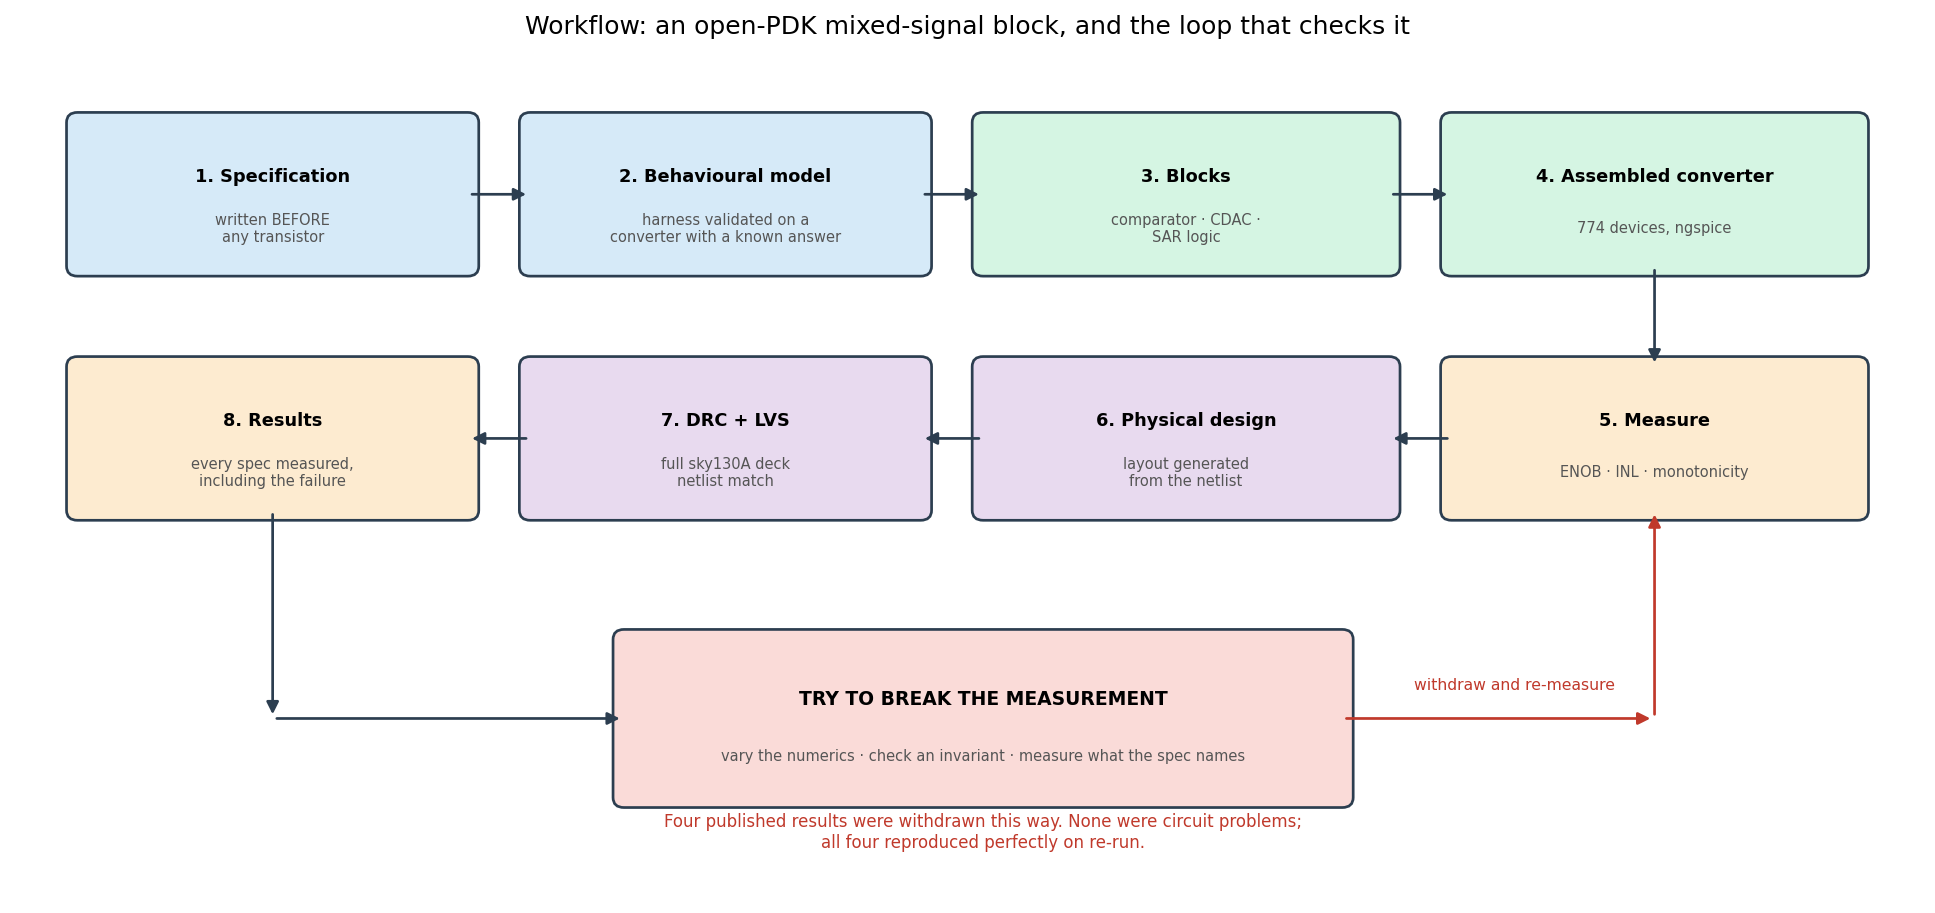

*The workflow this notebook follows. Not specific to this converter — the same sequence applies to any mixed-signal block in an open PDK. Regenerate with `make_schematics.py`.*


---
## 1. Environment

Everything runs on a free Colab instance from a cold start: ngspice for simulation, the sky130
PDK pinned by commit through `volare`, KLayout for physical verification, `gdstk` for layout
generation.

Install layout + verification tools  (~30 s, no PDK download needed)

In [1]:
import subprocess, sys, os, time
T_START = time.time()        # end-to-end runtime: measured by the last cell, not asserted here
def sh(c): return subprocess.run(c, shell=True, capture_output=True, text=True).stdout

# The Python packages the whole notebook uses: gdstk and klayout for layout and geometry,
# numpy and matplotlib for analysis and figures. About 30 s, and no PDK download.
sh(f"{sys.executable} -m pip install -q gdstk klayout numpy matplotlib")

import numpy as np, gdstk, klayout.db as kdb
print("klayout :", kdb.__version__ if hasattr(kdb,'__version__') else "ok")
print("gdstk   :", gdstk.__version__)

# Two sections fetch more than this, and each does it when you reach it rather than now:
#
#   Section 7  ngspice and the sky130 PDK pinned by commit (~220 MB), then simulates the
#              774-device netlist live in your session
#   Section 8  the klayout BINARY and zstd, for the official sky130A_mr.drc deck -- the pip
#              module installed above has no Ruby DRC engine and cannot run a deck
#
# Pinning by commit is not optional -- an unpinned PDK makes every number unreproducible.
print("\nngspice, the PDK and the klayout binary are installed by Sections 7 and 8.")


klayout : 0.30.12
gdstk   : 1.0.1

ngspice, the PDK and the klayout binary are installed by Sections 7 and 8.


---
## 2. The converter

A charge-redistribution SAR: a binary-weighted MiM capacitor DAC, a StrongARM comparator, and a
one-hot sequencer that runs one bit trial per phase, MSB first.

Bit naming, because it is easy to read the rest of this backwards. Trial index runs
MSB-first: trial 0 decides the MSB (weight 128) and trial 7 decides the LSB (weight 1).
The netlist nodes `q0..q7` follow that order, so `q7` is the *eighth trial* and the *least*
significant bit — not "bit 7" in the usual byte sense, where bit 7 is the MSB.

| | |
|---|---|
| resolution | 8 bit |
| sample rate | 1 MS/s (100 ns per bit trial) |
| supply | 1.8 V |
| input range | 0 to V_ref, single-ended |
| unit capacitor | MiM, 1.4 x 1.4 µm, **4.830 fF** measured |

The unit capacitance here is the measured 4.830 fF, not the 3.92 fF an area-only
estimate gives. Section 8 fits the sky130 model across three geometries and finds the
perimeter term is 19 % of a 1.4 × 1.4 µm unit — an earlier draft of this table carried the
area-only figure and was wrong by that much.

The specification was written before any transistor existed — in the behavioural notebook,
against an ideal model — so that the measurement harness could be validated on a converter whose
answer was already known.

### Schematics

The block diagram is rendered by `make_schematics.py` from the same device widths the netlist
uses. The comparator and the capacitor DAC are drawn in xschem against the sky130 symbol
library, so the devices in those two figures are the PDK's own primitives carrying the W/L
values Section 7 simulates, not a redrawing of them. All three are embedded as images rather
than generated at run time.


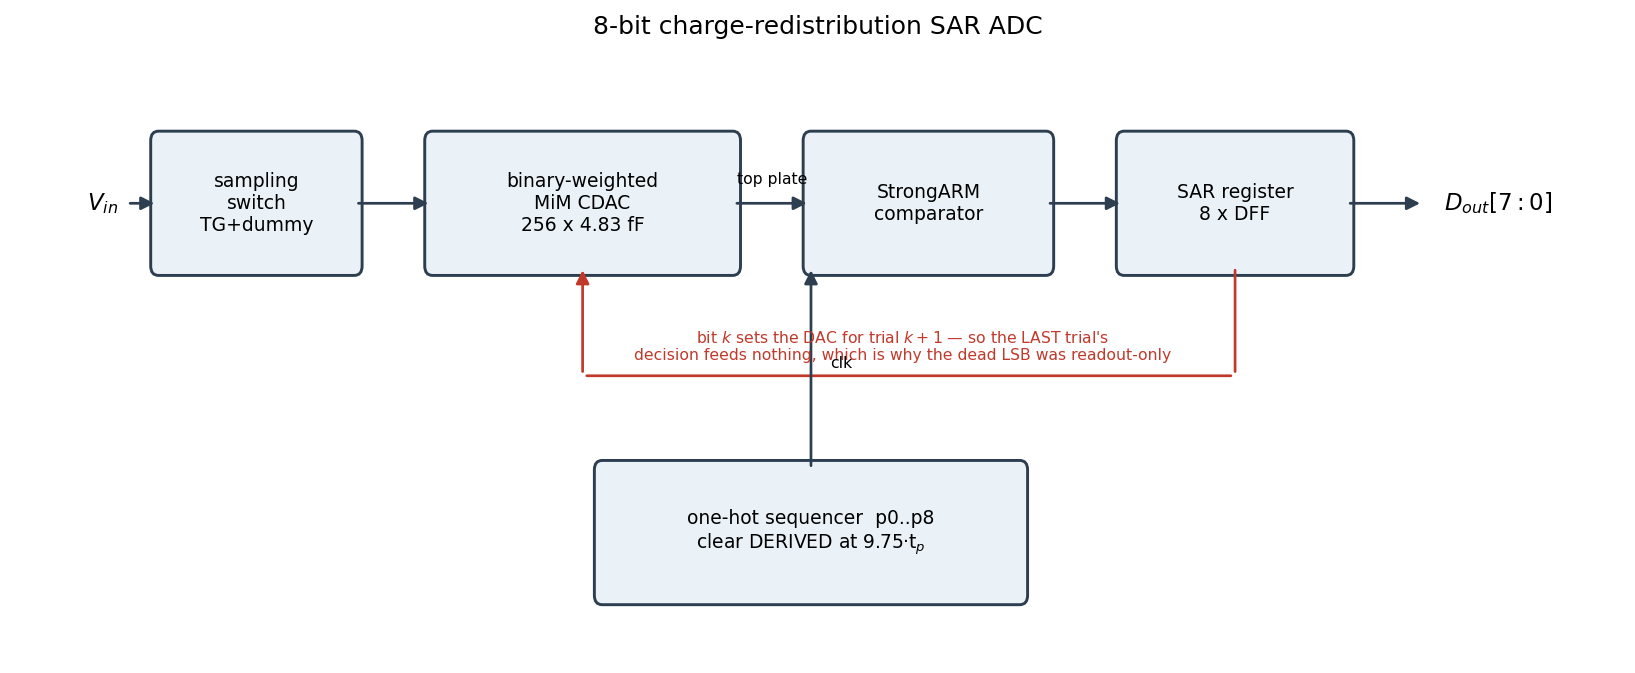

*8-bit charge-redistribution SAR ADC. Bit *k* sets the DAC for trial *k+1*, so the final trial's decision feeds nothing — which is why the dead LSB of Section 3 was a readout fault and left the analog behaviour untouched.*


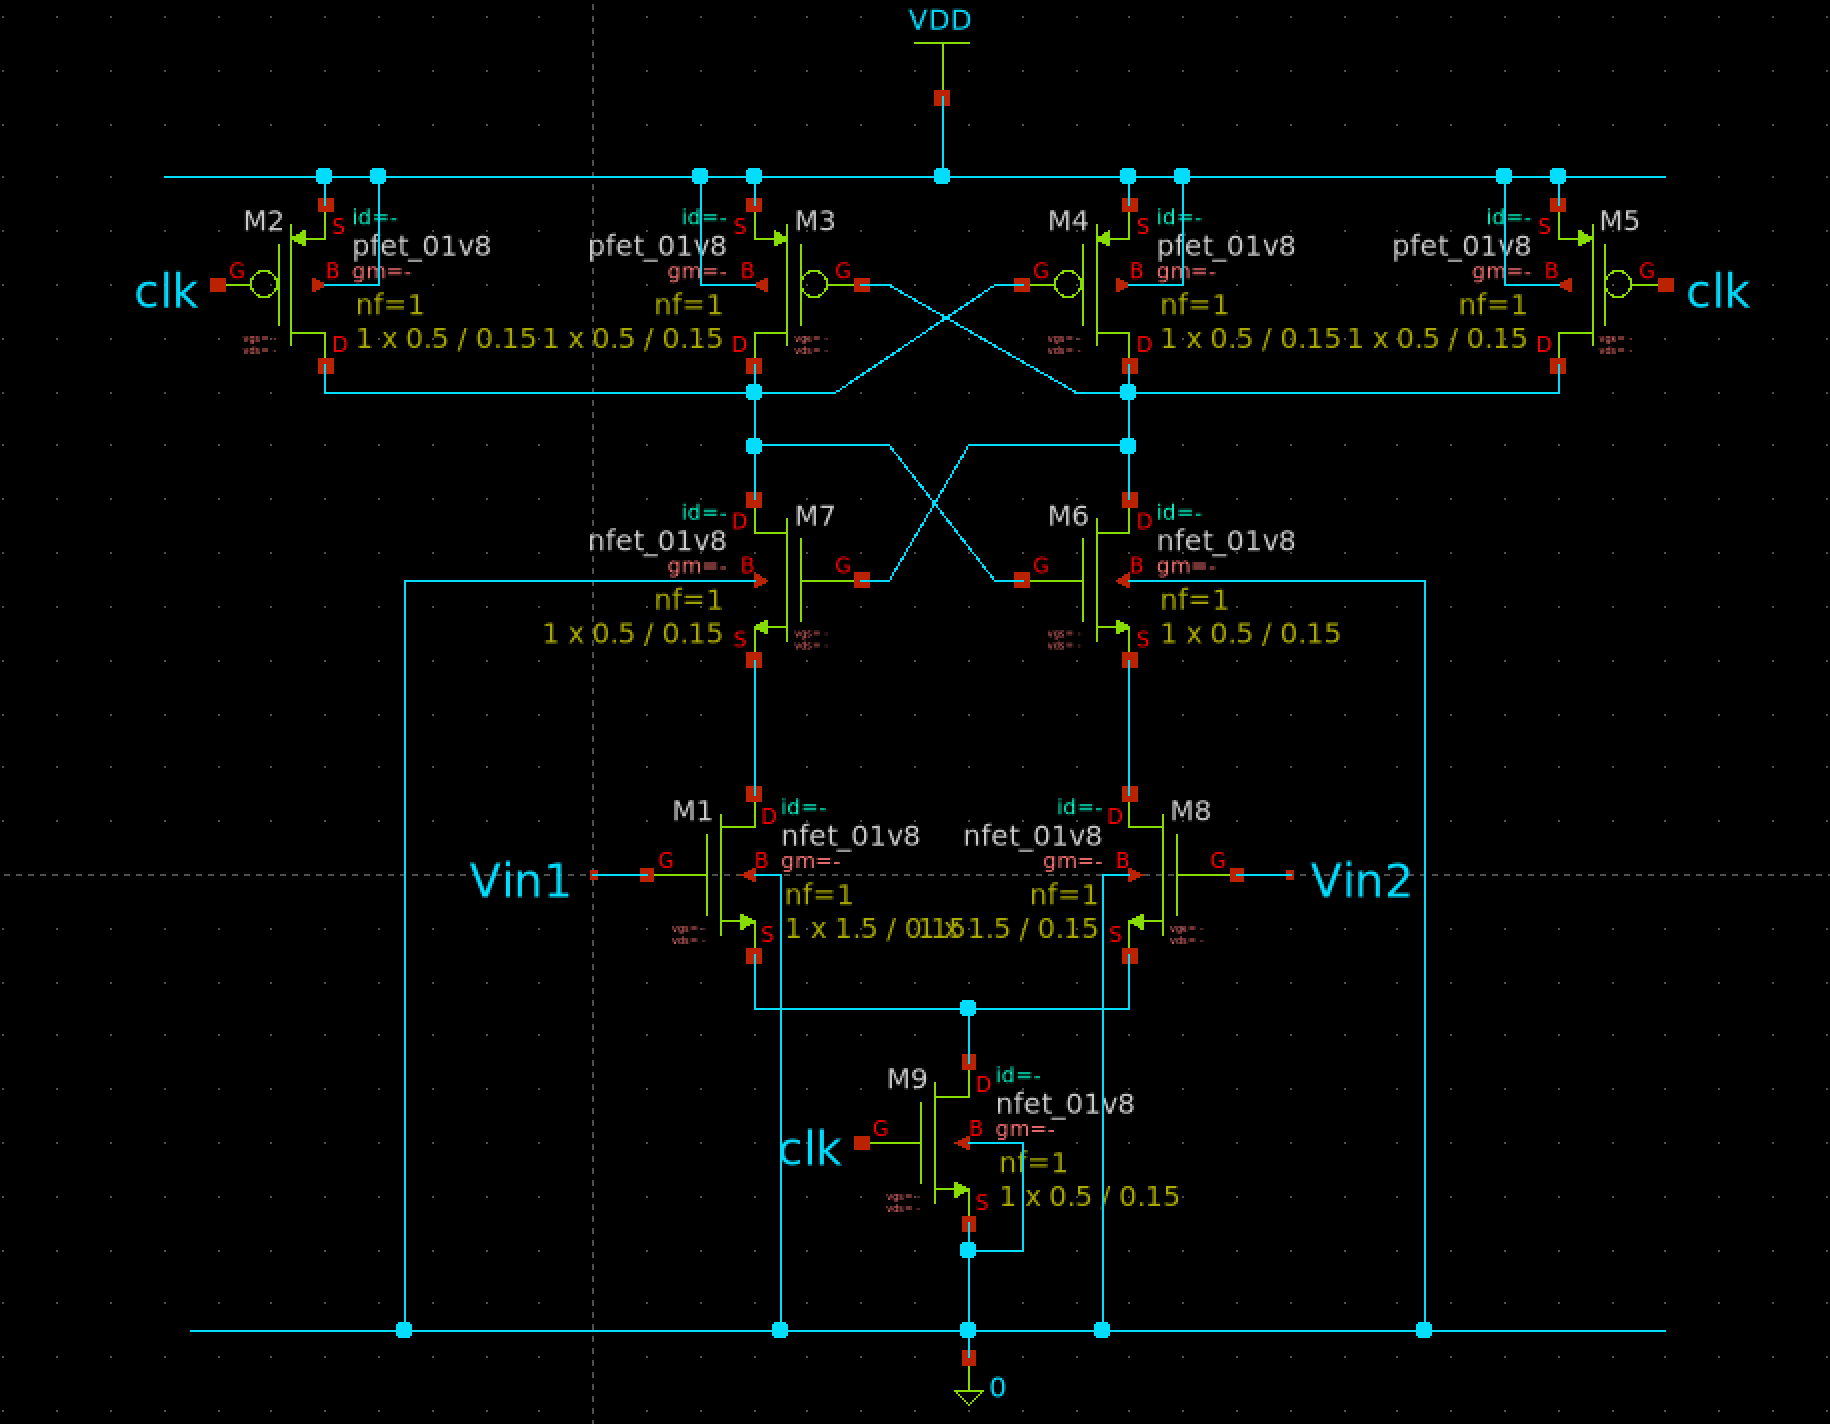

*StrongARM comparator, drawn in xschem against the sky130 symbol library. With `clk` low, M2 and M5 reset both output nodes to V<sub>DD</sub> and the tail M9 is off, so the latch holds no state and draws no current. On the rising edge the tail turns on and the input pair M1/M8 discharges the two nodes at rates set by V<sub>in1</sub> and V<sub>in2</sub>; the cross-coupled M3/M4 and M6/M7 then regenerate, driving whichever side fell first to ground and the other to V<sub>DD</sub>. Static current is zero in both phases, which is why a 1 MS/s converter spends almost nothing on its decision. Input devices are W = 1.5 µm, every other device 0.5 µm, all at L = 0.15 µm — the widths the netlist in Section 7 simulates.*

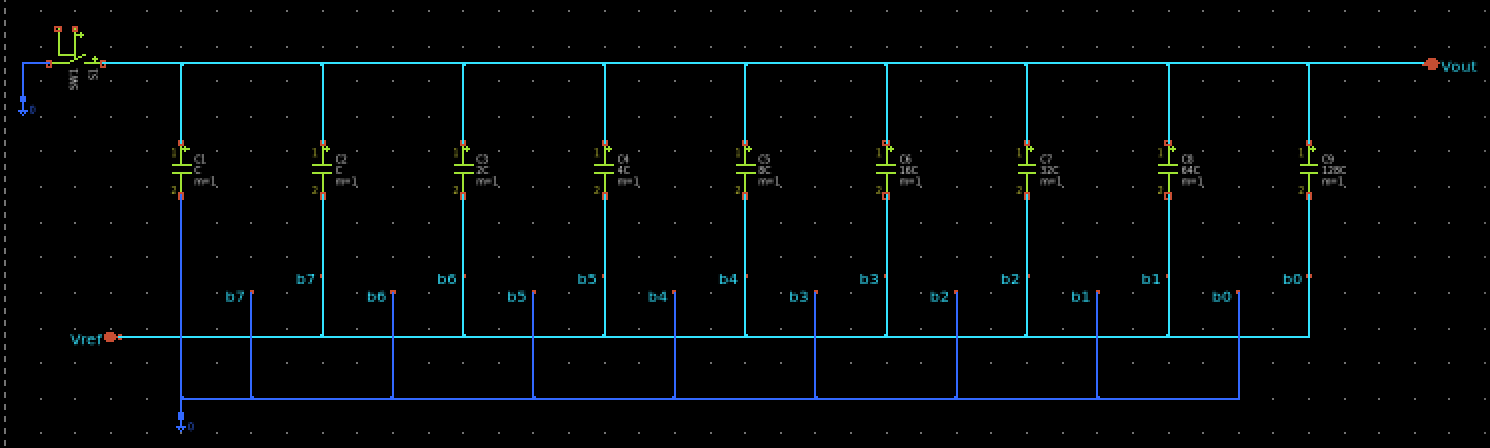

*Charge-redistribution DAC, drawn in xschem. The top plate is common and floats after sampling; each bottom plate switches between V<sub>ref</sub> and ground under its own decided bit. Bit indexing runs MSB-first — `b0` controls the 128C branch, `b7` the unit cap — matching the sequencer, which decides the MSB on trial 0. The ninth capacitor is a dummy, tied off so the edge unit sees the same surroundings as its neighbours.*


---
## 3. Finding 1 — the converter had no LSB, and the evidence was in the first result

Every code range this project ever printed was even-bounded:

```
4..254    6..250    8..250    8..252    132..170    174..212    216..252
```

Every bound is even. Across 95 conversions of a ramp with points spaced 1 LSB apart around
every major carry, the number of odd codes was zero. A converter whose output is never odd has no
LSB. That is not a linearity problem; it is a bit that does not exist — and it sat in notebook
output for weeks while increasingly careful *analog* explanations were built for the error floor
it produced.

### Cause

A conversion runs `N+1` sequencer phases. Trial *i* is captured when `cap_i = NAND(p_{i+1}, cclk)`
rises — the *falling* edge of the comparator clock — at `(i + 1.95 + 0.30)*t_p`. For the eighth
trial that is **9.25*t_p**, a quarter phase *past* the end of the phase sequence. The
code-register clear was hardcoded to `9*t_p`, the end of that sequence, so it asserted before the
LSB was captured; and the register was read at `8.95*t_p`, also before the capture edge.

Both faults land on the eighth trial alone, because every earlier trial has a whole phase of room.
**The hardcoded `9*t_p` is safe at N = 6, 10 and 12 and collides only at N = 8.**

The timing collision, derived rather than asserted

In [2]:
CCLK_RISE, CCLK_W = 0.95, 0.30       # comparator clock: rise and pulse width, in units of t_p
OLD_CLEAR, CLEAR_W = 9.0, 0.80       # the hardcoded clear that caused the bug

print(f"{'N':>3}{'last capture':>15}{'old clear window':>20}   collides?")
for N in (6, 8, 10, 12):
    cap_last = N + CCLK_RISE + CCLK_W            # capture edge of the final trial
    lo, hi   = OLD_CLEAR, OLD_CLEAR + CLEAR_W
    bad = lo <= cap_last <= hi
    print(f"{N:>3}{cap_last:>13.2f}tp   {lo:>6.2f}..{hi:<6.2f}tp   "
          f"{'*** YES ***' if bad else 'no'}")

print("\nThe constant was placed at the END of the phase sequence, (N+1)*tp = 9tp for N=8.")
print("The last capture edge falls a quarter phase PAST the end of its own phase.")

  N   last capture    old clear window   collides?
  6         7.25tp     9.00..9.80  tp   no
  8         9.25tp     9.00..9.80  tp   *** YES ***
 10        11.25tp     9.00..9.80  tp   no
 12        13.25tp     9.00..9.80  tp   no

The constant was placed at the END of the phase sequence, (N+1)*tp = 9tp for N=8.
The last capture edge falls a quarter phase PAST the end of its own phase.


### What a stuck LSB predicts, and what was measured

A converter missing its LSB quantises in steps of 2 LSB. That alone predicts the error floor —
no analog mechanism required:

| | predicted by a stuck LSB alone | measured |
|---|---|---|
| quantisation step | 2 LSB | codes even-only |
| residual rms | 2/sqrt(12) = **0.577 LSB** | 0.60, 0.61, 0.65, 0.66, 0.67 |
| ENOB ceiling | **7.00 b** | 6.80, 6.93, 6.95 |

The residual also tracks position inside the 2-LSB step one-for-one, then wraps negative — a
textbook stuck-bit sawtooth.

This is why the earlier "not settling-limited" conclusion was unsound. A sweep of bit-trial
length showed ENOB flat at 6.53–6.95 across a 4x span, which was read as proof that more settling
time buys nothing. But that flatness *was* the 7.00 bit ceiling, with the sweep points sitting
just underneath it. Settling was never given room to show itself.

A stuck LSB reproduces the measured error floor from nothing but quantisation

LSB working  (1 LSB steps):  residual rms 0.289 LSB   ENOB ceiling 8.00 b
LSB stuck    (2 LSB steps):  residual rms 0.577 LSB   ENOB ceiling 7.00 b

measured, before the fix:  rms 0.60-0.67 LSB,  ENOB 6.80-6.95 b
-> the floor is fully accounted for by the missing bit. No analog mechanism needed.


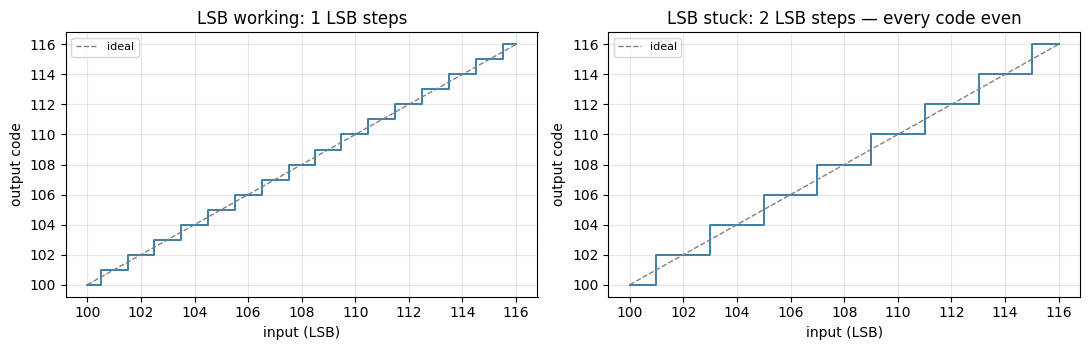

A converter whose output is never odd has no LSB. That was visible in the
first printed code range, and went unread for weeks.


In [3]:
import numpy as np
rs = np.random.RandomState(0)
v = rs.uniform(10, 240, 20000)

for name, step in (("LSB working  (1 LSB steps)", 1.0), ("LSB stuck    (2 LSB steps)", 2.0)):
    c = step*np.round(v/step)
    r = v - c; r -= r.mean()
    print(f"{name}:  residual rms {r.std():.3f} LSB   ENOB ceiling "
          f"{8-np.log2(r.std()*np.sqrt(12)):.2f} b")

print("\nmeasured, before the fix:  rms 0.60-0.67 LSB,  ENOB 6.80-6.95 b")
print("-> the floor is fully accounted for by the missing bit. No analog mechanism needed.")


import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
v = np.linspace(100, 116, 400)
for a, step, name in ((ax[0], 1.0, "LSB working"), (ax[1], 2.0, "LSB stuck")):
    c = step*np.round(v/step)
    a.step(v, c, where="mid", lw=1.4, color="#3d7ea6")
    a.plot(v, v, "--", c="grey", lw=1, label="ideal")
    a.set(xlabel="input (LSB)", ylabel="output code", title=f"{name}: {step:.0f} LSB steps")
    a.grid(alpha=0.3); a.legend(fontsize=8)
ax[1].set_title("LSB stuck: 2 LSB steps — every code even")
plt.tight_layout(); plt.show()
print("A converter whose output is never odd has no LSB. That was visible in the")
print("first printed code range, and went unread for weeks.")

### The fix, and why it is derived rather than patched

The bug existed because two constants had to agree and nothing checked that they did: the
sequencer's phase count, and the clear window. Moving the clear by four characters fixes this
instance; deriving it from the bit count fixes the class.

Both faults were shown to be independently fatal, which is a measurement rather than a reading
of the waveform:

| variant | read | clear | odd codes | ENOB |
|---|---|---|---|---|
| original | 8.95*t_p | 9.00*t_p | 0 | 6.90 |
| clear fixed only | 8.95*t_p | 9.75*t_p | 0 | **6.90** (identical) |
| **both fixed** | 9.50*t_p | 9.75*t_p | **22 of 40** | **7.37** |

Fixing the clear alone reproduces the original *exactly* — the two decks were diffed and differ by
exactly one line, so this is isolation and not a sweep that failed to reach the simulator. And
scanning every read time across a full conversion under the old clear recovers the LSB at no
instant, because the flip-flop clears its master as well as its slave: the value is erased, not
merely masked.

Derived timing: the clear follows from the bit count, and the ordering is asserted

In [4]:
CCLK_RISE, CCLK_W = 0.95, 0.30
READ_MARGIN, CLEAR_MARGIN, CLEAR_W = 0.25, 0.25, 0.50
MIN_ABS_MARGIN = 1e-9      # gate delays do NOT scale with t_p

def timing(N, tp):
    tconv = (N + 2)*tp
    cap   = [(i + 1 + CCLK_RISE + CCLK_W)*tp for i in range(N)]
    t_read  = cap[-1] + READ_MARGIN*tp
    t_clear = t_read  + CLEAR_MARGIN*tp
    assert t_read > cap[-1],  "read precedes the last capture"
    assert t_clear > t_read,  "clear preempts the read"
    for i, c in enumerate(cap):
        assert c < t_clear,   f"trial {i} captures inside the clear"
    assert t_clear + CLEAR_W*tp < tconv + cap[0], "clear runs into the next conversion"
    m = min(t_read - cap[-1], t_clear - t_read)
    # margins are fractions of t_p, so the ORDER is scale-invariant -- but gate delays are
    # not, so a short t_p can violate in seconds what holds in units of t_p.
    assert m >= MIN_ABS_MARGIN, f"margin {m*1e12:.0f} ps below the gate-delay floor"
    return dict(cap_last=cap[-1], read=t_read, clear=t_clear, margin=m)

for N in (6, 8, 10, 12):
    t = timing(N, 100e-9)
    print(f"N={N:>2}: last capture {t['cap_last']/100e-9:5.2f}tp  "
          f"read {t['read']/100e-9:5.2f}tp  clear {t['clear']/100e-9:5.2f}tp")
print("\nSame assertions across trial length -- the sweep that would otherwise re-break it:")
for tp in (200e-9, 100e-9, 50e-9, 20e-9, 10e-9):
    print(f"   t_p={tp*1e9:6.1f} ns  margin {timing(8,tp)['margin']*1e12:7.0f} ps  ok")

N= 6: last capture  7.25tp  read  7.50tp  clear  7.75tp
N= 8: last capture  9.25tp  read  9.50tp  clear  9.75tp
N=10: last capture 11.25tp  read 11.50tp  clear 11.75tp
N=12: last capture 13.25tp  read 13.50tp  clear 13.75tp

Same assertions across trial length -- the sweep that would otherwise re-break it:
   t_p= 200.0 ns  margin   50000 ps  ok
   t_p= 100.0 ns  margin   25000 ps  ok
   t_p=  50.0 ns  margin   12500 ps  ok
   t_p=  20.0 ns  margin    5000 ps  ok
   t_p=  10.0 ns  margin    2500 ps  ok


---
## 4. Finding 2 — ngspice's default tolerance cannot resolve 8 bits

With the LSB latching, the converter measured 7.37 — a *ramp ceiling*, not ENOB at Nyquist; see the note in Section 5 and the measurement in Section 9. That number was also wrong, for a
completely different reason.

Running the identical deck and the identical input sweep at different solver tolerances:

| tolerance | codes differing from default | max difference | monotonic? |
|---|---|---|---|
| default `reltol=1e-3` | — | — | **no** |
| `reltol=1e-4 vntol=1e-7` | **7 of 28** | 2 LSB | yes |
| `reltol=1e-5 vntol=1e-8` | 8 of 28 | 2 LSB | yes |

A quarter of the measured codes are wrong at the default, by up to 2 LSB, in an 8-bit converter.
On a 40-point linearity ramp the same change moved ENOB from 7.37 to 8.05 — 0.68 bits, from a
solver setting, with no circuit change at all.

### Why this one survived scrutiny

The error is perfectly reproducible. Three independent invocations of the same deck produced
identical glitches at identical inputs. Every instinct says reproducible means physical, so the
artefacts read as circuit behaviour — a missing code at 133, a non-monotonic transfer curve — and
they *survived* repetition, because repeating a deterministic error confirms it.

What exposes them is varying the numerics, not repeating the measurement. The missing code
appears in one ramp and is present three times in another, because local truncation error depends
on timestep history, which depends on the entire waveform preceding it.

> Validate solver tolerance against the resolution you intend to claim, before measuring.
> A converter resolving 1.8 V / 256 = 7.03 mV cannot be characterised by a solver accepting
> ~1e-3 relative error on node voltages. This is one run to check, and it was not checked here
> for weeks.

One caution: do not tighten `abstol`, `chgtol` and `trtol` reflexively. Setting
`chgtol=1e-16` with `trtol=1` drove the timestep to 1.25e-21 against a 50 ps source edge and
aborted the run. `reltol` and `vntol` are the ones that govern accepted local truncation error;
`1e-4` costs about 2.4x runtime.

---
## 5. Finding 3 — an ENOB above the theoretical ceiling is an estimator, not a converter

At `reltol=1e-4` the converter measured ENOB 8.05. That is impossible: a Nyquist 8-bit
converter without oversampling is bounded at 8.00 bits by quantisation alone, so a real
measurement must land below it.

Exceeding the bound means the *estimator* is biased. The cause is record length — and the error is
a bias, not scatter, so the +/-0.16 quoted alongside it did not cover the problem.

An IDEAL converter, zero analog error: what the estimator reports vs record length

     N   mean ENOB             5-95%
    32        8.05    7.85.. 8.27  <-- above the 8.00 ceiling
    40        8.05    7.88.. 8.22  <-- above the 8.00 ceiling
    64        8.03    7.89.. 8.16  <-- above the 8.00 ceiling
   160        8.01    7.93.. 8.10  <-- above the 8.00 ceiling
   520        8.00    7.96.. 8.06
  1024        8.00    7.97.. 8.04
  4096        8.00    7.99.. 8.02

The ceiling is 8.00. A short record reports MORE than that from a perfect converter,
because quantisation error is not white over few samples and the noise sum runs low.
The measured 8.05 at N=40 was exactly this artefact -- it said nothing about the circuit.


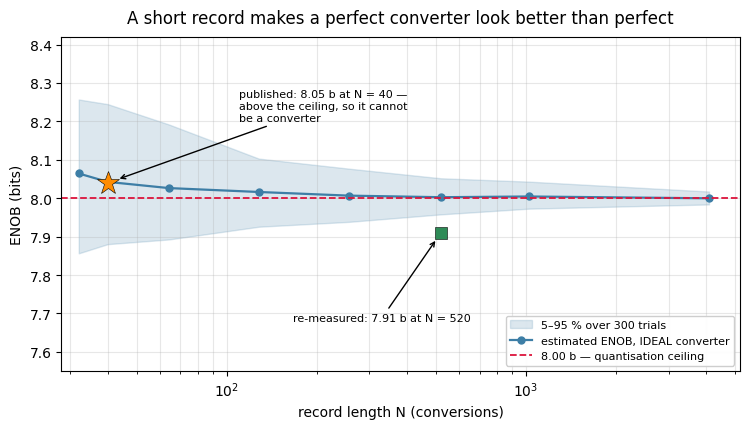

In [5]:
import numpy as np
rs = np.random.RandomState(0)

print(f"{'N':>6}{'mean ENOB':>12}{'5-95%':>18}")
for n in (32, 40, 64, 160, 520, 1024, 4096):
    es = []
    for _ in range(400):
        v = np.sort(rs.uniform(10, 240, n))
        c = np.round(v)                                  # ideal quantisation, nothing else
        g, o = np.polyfit(c, v, 1); r = (v - (g*c + o))/g
        es.append(8 - np.log2(r.std()*np.sqrt(12)))
    es = np.array(es)
    flag = "  <-- above the 8.00 ceiling" if es.mean() > 8.005 else ""
    print(f"{n:>6}{es.mean():>12.2f}   {np.percentile(es,5):5.2f}..{np.percentile(es,95):5.2f}{flag}")

print("\nThe ceiling is 8.00. A short record reports MORE than that from a perfect converter,")
print("because quantisation error is not white over few samples and the noise sum runs low.")
print("The measured 8.05 at N=40 was exactly this artefact -- it said nothing about the circuit.")


import matplotlib.pyplot as plt
Ns = [32, 40, 64, 128, 256, 520, 1024, 4096]
mean, lo, hi = [], [], []
for n in Ns:
    es = []
    for _ in range(300):
        v = np.sort(rs.uniform(10, 240, n)); c = np.round(v)
        g, o = np.polyfit(c, v, 1); r = (v - (g*c + o))/g
        es.append(8 - np.log2(r.std()*np.sqrt(12)))
    es = np.array(es)
    mean.append(es.mean()); lo.append(np.percentile(es,5)); hi.append(np.percentile(es,95))

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.fill_between(Ns, lo, hi, alpha=0.18, color="#3d7ea6", label="5–95 % over 300 trials")
ax.semilogx(Ns, mean, "o-", color="#3d7ea6", lw=1.6, ms=5,
            label="estimated ENOB, IDEAL converter")
ax.axhline(8.0, ls="--", c="crimson", lw=1.3, label="8.00 b — quantisation ceiling")

ax.plot(40, 8.04, "*", ms=17, color="darkorange", mec="k", mew=0.4, zorder=5)
ax.annotate("published: 8.05 b at N = 40 —\nabove the ceiling, so it cannot\nbe a converter",
            xy=(40, 8.04), xytext=(110, 8.24), fontsize=8, va="center",
            arrowprops=dict(arrowstyle="->", lw=1, shrinkB=9))

ax.plot(520, 7.91, "s", ms=8, color="seagreen", mec="k", mew=0.4, zorder=5)
ax.annotate("re-measured: 7.91 b at N = 520", xy=(520, 7.91), xytext=(330, 7.68),
            fontsize=8, ha="center", arrowprops=dict(arrowstyle="->", lw=1, shrinkB=7))

ax.set_xlim(28, 5200); ax.set_ylim(7.55, 8.42)
ax.set(xlabel="record length N (conversions)", ylabel="ENOB (bits)")
ax.set_title("A short record makes a perfect converter look better than perfect", pad=10)
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8, loc="lower right", framealpha=0.95)
plt.tight_layout(); plt.show()


### Re-measured on a long record

ENOB re-measured at N = 520, batched at 40 conversions per transient to stay inside the
~61 us transient ceiling. Batching is safe here: a separate test showed zero code differences
at batch boundaries, because each batch spans exactly the sub-range a single long ramp would cover.

| N (random subsamples of the full record) | mean ENOB |
|---|---|
| 40 | 7.96 |
| 160 | 7.92 |
| **520** | **7.91** |

7.91 bits, converging from *above* as a positively-biased estimator must. The implied
analog residual is 0.104 LSB — against a < 0.11 LSB bound predicted before the run.

> Read 7.91 as a ceiling, not as ENOB. It is `8 − log₂(rms·√12)` of a *ramp's* fit residual:
> static linearity re-expressed in bits. It ignores noise, and a near-DC sweep exercises no
> settling, no slewing and no large-step acquisition. The specification names ENOB at Nyquist,
> measured from the SNDR of a coherent sine in Section 9 — where this converter reads 7.16 b.
> The ramp is 0.80 b optimistic, and that gap is finding 12. Everything in Sections 4 and 5 is
> about the ceiling; the spec number arrives later and is lower.

That bound is the real result. The analog non-linearity this project spent most of its length
hunting — junction capacitance on the top plate, comparator kickback, sampling-switch acquisition —
is below what the harness can detect. It was a digital timing collision plus a solver setting.

---
## 6. Finding 4 — a linearity fit must exclude saturated codes

A 95-point ramp appeared to show 4.33 LSB of INL concentrated in the top 8% of the input
range, against ~1.0 LSB elsewhere. It was written up as the largest unexplained problem in the
design, and it was reviewed twice in that form.

It was one point. At v_in = 1.8000 V the ideal code is 256.0 — outside an 8-bit range — and
the converter correctly returns 255. That is saturation, not non-linearity, and a clipped
endpoint does not belong in a linearity regression.

One clipped endpoint moves peak INL by 3.2 LSB

all points, including the clipped endpoint    n= 95  rms 0.346  peak  0.90 LSB
saturated codes excluded (0 < code < 255)     n= 93  rms 0.337  peak  0.70 LSB

The converter is identical in both rows. Only the fit changed.


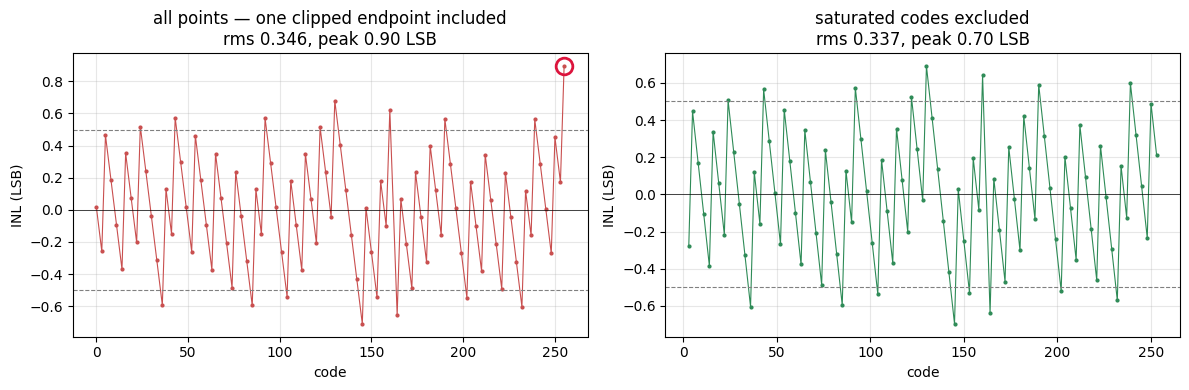

Same converter in both panels. Only the fit changed.


In [6]:
import numpy as np
LSB = 1.8/256
rs = np.random.RandomState(3)
v = np.linspace(0.0, 1.8, 95)
c = np.clip(np.round(v/LSB + rs.randn(95)*0.15), 0, 255)   # a converter that saturates at 255

for label, m in (("all points, including the clipped endpoint", np.ones(95, bool)),
                 ("saturated codes excluded (0 < code < 255)", (c > 0) & (c < 255))):
    g, o = np.polyfit(c[m], v[m], 1); inl = (v[m] - (g*c[m] + o))/g
    print(f"{label:<44}  n={m.sum():3d}  rms {inl.std():.3f}  peak {np.abs(inl).max():5.2f} LSB")

print("\nThe converter is identical in both rows. Only the fit changed.")


import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (label, m) in zip(ax, (("all points — one clipped endpoint included", np.ones(95, bool)),
                              ("saturated codes excluded", (c > 0) & (c < 255)))):
    g, o = np.polyfit(c[m], v[m], 1); inl = (v[m] - (g*c[m] + o))/g
    a.plot(c[m], inl, ".-", ms=4, lw=0.8, color="#c94f4f" if m.all() else "seagreen")
    a.axhline(0, c="k", lw=0.5)
    for s in (0.5, -0.5): a.axhline(s, ls="--", c="grey", lw=0.8)
    a.set(xlabel="code", ylabel="INL (LSB)",
          title=f"{label}\nrms {inl.std():.3f}, peak {np.abs(inl).max():.2f} LSB")
    a.grid(alpha=0.3)
ax[0].plot(255, ((v-(np.polyfit(c,v,1)[0]*c+np.polyfit(c,v,1)[1]))/np.polyfit(c,v,1)[0])[-1],
           "o", ms=12, mfc="none", mec="crimson", mew=2)
plt.tight_layout(); plt.show()
print("Same converter in both panels. Only the fit changed.")

Re-measured at 0.46 LSB steps with ~30x the density in the region concerned, the error is
uniform across the range:

| region | \|INL\| max | rms |
|---|---|---|
| bottom 8% | 0.73 LSB | 0.29 |
| middle | 0.63 LSB | 0.30 |
| top 8% | **0.56 LSB** | 0.29 |

The top is now the *best* region. There was never an asymmetry to explain.

---
## 7. The converter, simulated

Everything above reproduces a *finding* from a model. This section runs the actual circuit:
774 transistor-level devices against the sky130 models, in ngspice, and measures the numbers
Section 9 reports.

What runs, and how long it takes — stated once.

The flow runs live: this section installs a pinned PDK (~220 MB), builds 774 devices, and
converts 40 samples through the real circuit in about 2 minutes locally, 7–13 on Colab.
Cell-for-cell, a reader watches the converter work.

The long records — 520 ramp conversions and 3 × 512 coherent-sine conversions — are hours of
simulation. They are embedded in this notebook and scored below by the same code that
produced them, because *waiting is not reproducing*. Nothing here asks you to re-simulate an
afternoon to read a number.

The live 40-conversion run is not filler: at that record length it measures ENOB 8.05 b,
above the 8.00 b quantisation ceiling, reproducing Section 5's estimator bias **on the real
converter, in your session**.

Two settings that are not defaults and are not optional:

- `reltol=1e-4`. At ngspice's default this converter returns 7 of 28 codes wrong by up to
  2 LSB (Section 4). Costs ~2.4x runtime.
- The conversion timing is derived from the bit count, not written down twice (Section 3).

In [7]:
# Install ngspice and the sky130 PDK, pinned by commit.
# An unpinned PDK makes every number below unreproducible.
import os, sys, shutil, subprocess, pathlib, tempfile, time
import numpy as np

IN_COLAB = "google.colab" in sys.modules
if shutil.which("ngspice") is None and IN_COLAB:
    subprocess.run("apt-get -qq update && apt-get -qq install -y ngspice zstd",
                   shell=True, check=False)

PDK_HASH = "c6d73a35f524070e85faff4a6a9eef49553ebc2b"
PDK_ROOT = pathlib.Path(os.environ.get("PDK_ROOT",
                        "/content/pdk" if IN_COLAB else "./pdk")).resolve()
CORNER_LIB = PDK_ROOT / "sky130A/libs.tech/ngspice/sky130.lib.spice"
if not CORNER_LIB.exists():
    PDK_ROOT.mkdir(parents=True, exist_ok=True)
    base = f"https://github.com/chipfoundry/volare/releases/download/sky130-{PDK_HASH}"
    for asset in ("common", "sky130_fd_pr"):
        tar = PDK_ROOT.parent / f"{asset}.tar.zst"
        if not tar.exists():
            subprocess.run(["curl", "-sL", "--fail", "-o", str(tar),
                            f"{base}/{asset}.tar.zst"], check=False)
        subprocess.run(["tar", "--zstd", "-xf", str(tar), "-C", str(PDK_ROOT)], check=False)

HAVE_SPICE = shutil.which("ngspice") is not None and CORNER_LIB.exists()
# Report presence, not absolute paths: this notebook is published, and the full path
# would carry whoever ran it last into a public repository.
print("ngspice :", "found" if shutil.which("ngspice") else "NOT FOUND")
print("PDK     :", f"found (sky130A, pinned {PDK_HASH[:8]})" if CORNER_LIB.exists()
                   else "NOT FOUND")
print("\nsimulation enabled" if HAVE_SPICE else
      "\nSPICE cells will be skipped; the behavioural sections above are unaffected.")

TOL = ".options reltol=1e-4 vntol=1e-7"     # Section 4: the default cannot resolve 8 bits

def run_ngspice(body, control, extra="", corner="tt", timeout=7200):
    """One ngspice deck. The scratch dir is removed in a finally -- without it every call
    leaks a mkdtemp, which on a Colab VM eventually presents as a silent kill."""
    wd = pathlib.Path(tempfile.mkdtemp())
    try:
        (wd/"d.sp").write_text(f"* sar\n.lib {CORNER_LIB} {corner}\n{TOL}\n{extra}\n{body}\n"
                               f".control\n{control}\n.endc\n.end\n")
        r = subprocess.run(["ngspice","-b","d.sp"], cwd=wd, capture_output=True,
                           text=True, timeout=timeout)
        out = wd/"out.csv"
        data = np.loadtxt(out) if out.exists() and out.stat().st_size else None
        return data, r.stdout + r.stderr
    finally:
        shutil.rmtree(wd, ignore_errors=True)

ngspice : found
PDK     : found (sky130A, pinned c6d73a35)

simulation enabled


In [8]:
# Standard-cell primitives, built from sky130 transistors.
NF, PF = "sky130_fd_pr__nfet_01v8", "sky130_fd_pr__pfet_01v8"
VDD = 1.8

def inv(name, i, o, wn=0.65, wp=1.3, L=0.15):
    return [f"XN{name} {o} {i} 0 0 {NF} W={wn} L={L}",
            f"XP{name} {o} {i} vdd vdd {PF} W={wp} L={L}"]

def tg(name, a, b, en, enb, wn=0.65, wp=1.3, L=0.15):
    """transmission gate: conducts when en=1"""
    return [f"XNt{name} {a} {en} {b} 0 {NF} W={wn} L={L}",
            f"XPt{name} {a} {enb} {b} vdd {PF} W={wp} L={L}"]

def nor2(name, a, b, o, wn=0.65, wp=2.6, L=0.15):
    """2-input NOR: series PMOS (hence the wider p), parallel NMOS."""
    return [f"XPa{name} {name}_pi {a} vdd vdd {PF} W={wp} L={L}",
            f"XPb{name} {o} {b} {name}_pi vdd {PF} W={wp} L={L}",
            f"XNa{name} {o} {a} 0 0 {NF} W={wn} L={L}",
            f"XNb{name} {o} {b} 0 0 {NF} W={wn} L={L}"]


L_MIN_ = 0.15


def dff(name, d, q, clk, clkb, rst="0"):
    """Static master-slave D flip-flop, positive edge. Back-to-back inverters hold
    each stage, so nothing relies on charge storage -- see the leakage note."""
    m, mb, s, sb = f"{name}_m", f"{name}_mb", f"{name}_s", f"{name}_sb"
    L = []
    L += tg(f"{name}1", d, m, clkb, clk)          # master transparent when clk=0
    # Clear the MASTER as well as the slave. Clearing only the output leaves the master
    # holding an undefined value, which propagates the instant the slave turns
    # transparent -- invisible on a flip-flop whose clock is already toggling, and fatal
    # in a register that must start a conversion from a known state.
    if rst != "0":
        L += [f"XNrst{name} {m} {rst} 0 0 {NF} W=2.0 L={L_MIN_}"]
    L += inv(f"{name}mi", m, mb)
    L += inv(f"{name}mf", mb, f"{name}_fb")       # feedback inverter
    L += tg(f"{name}2", f"{name}_fb", m, clk, clkb)
    L += tg(f"{name}3", mb, s, clk, clkb)         # slave transparent when clk=1
    # s carries NOT(D); one inversion puts D on q. Taking q from the second
    # inverter instead would return NOT(D) -- an easy transistor to leave in.
    # That inverter is a NOR so the register has an asynchronous clear: without one
    # the flip-flop powers up in whichever state the DC solver happens to find, which
    # is not a state a conversion can start from.
    L += nor2(f"{name}si", s, rst, q)
    L += inv(f"{name}sf", q, f"{name}_sfb")
    L += tg(f"{name}4", f"{name}_sfb", s, clkb, clk)
    return L

# --- verify one flip-flop captures on the rising edge ---
# This is the cell whose asynchronous clear erased the LSB: it clears the MASTER as well as
# the slave, so a clear landing on the capture edge destroys the captured value rather than
# merely masking it. That is why no read time could recover it (Section 3).
if HAVE_SPICE:
    body  = ["Vdd vdd 0 1.8"]
    body += inv("ck", "clk", "clkb")
    body += dff("ff", "d", "q", "clk", "clkb")
    body += ["Vclk clk 0 PULSE(0 1.8 5n 0.1n 0.1n 5n 10n)",
             "Vd   d   0 PWL(0 0 2n 0 2.1n 1.8 12n 1.8 12.1n 0 22n 0 22.1n 1.8)"]
    data, log = run_ngspice("\n".join(body), "tran 20p 45n\nwrdata out.csv v(clk) v(d) v(q)")
    assert data is not None, log[-1500:]
    t, clk, d, q = data[:,0], data[:,1], data[:,3], data[:,5]
    print("DFF functional check (captures D on each rising clock edge):")
    print(f"{'t (ns)':>8s}{'clk':>7s}{'D':>7s}{'Q':>7s}")
    for tt in (4, 6, 11, 16, 21, 26, 31, 36, 41):
        k = np.argmin(np.abs(t - tt*1e-9))
        print(f"{tt:8.0f}{clk[k]:7.2f}{d[k]:7.2f}{q[k]:7.2f}")
else:
    print("SPICE unavailable -- flip-flop self-test skipped.")


DFF functional check (captures D on each rising clock edge):
  t (ns)    clk      D      Q
       4   0.00   1.80   1.80
       6   1.80   1.80   1.80
      11   0.00   1.80   1.80
      16   1.80   0.00   0.00
      21   0.00   0.00   0.00
      26   1.80   1.80   1.80
      31   0.00   1.80   1.80
      36   1.80   1.80   1.80
      41   0.00   1.80   1.80


In [9]:
# The complete converter: capacitor DAC, sampling switch, StrongARM comparator,
# decision capture, and the one-hot sequencer. 774 devices.
import re, time
MIM = "sky130_fd_pr__cap_mim_m3_1"
VCM, VREF, WL, L = 0.9, 1.8, 1.40, 0.15   # L = drawn channel length, um
N = 8
CMP = dict(w_tail=0.5, w_in=1.5, w_ln=0.5, w_lp=0.5, w_rst=0.5)

def or2(nm, a, b, o, wn=0.65, wp=2.6):
    return nor2(nm, a, b, f"{nm}_n") + inv(f"{nm}i", f"{nm}_n", o)


def nand2(nm, a, b, o, wn=1.3, wp=1.3):
    """2-input NAND: series NMOS, parallel PMOS."""
    return [f"XNa{nm} {o} {a} {nm}_ni 0 {NF} W={wn} L={L}",
            f"XNb{nm} {nm}_ni {b} 0 0 {NF} W={wn} L={L}",
            f"XPa{nm} {o} {a} vdd vdd {PF} W={wp} L={L}",
            f"XPb{nm} {o} {b} vdd vdd {PF} W={wp} L={L}"]


def tristate_inv(nm, i, o, en, enb, wn=1.0, wp=2.0):
    """Drives o to VREF or GND when en=1; floats when en=0."""
    return [f"XP1{nm} {nm}_p {i} vdd vdd {PF} W={wp} L={L}",
            f"XP2{nm} {o} {enb} {nm}_p vdd {PF} W={wp} L={L}",
            f"XN1{nm} {o} {en} {nm}_n 0 {NF} W={wn} L={L}",
            f"XN2{nm} {nm}_n {i} 0 0 {NF} W={wn} L={L}"]


def sar(w_drv=2.0, t_phase=100e-9, vin=0.9, n_phase=9):
    Nl = ["Vdd vdd 0 1.8", f"Vcm vcm 0 {VCM}", f"Vin vin 0 {vin}"]
    Nl += inv("ck", "clk", "clkb")

    # --- sequencer: p0 samples, p1..p8 are the bit trials
    for i in range(n_phase):
        Nl += dff(f"s{i}", "start" if i == 0 else f"p{i-1}", f"p{i}", "clk", "clkb", rst="rst")
    Nl += inv("p0i", "p0", "p0b")

    # --- capacitor array, one instance per unit cap
    for i in range(N):
        for k in range(2 ** (N - 1 - i)):
            Nl.append(f"Xc{i}_{k} top b{i} {MIM} W={WL} L={WL}")
        # bottom plate: to Vin while sampling, else driven to VREF/GND by d{i}
        Nl += tg(f"sm{i}", "vin", f"b{i}", "p0", "p0b")
        Nl += tristate_inv(f"dr{i}", f"d{i}b", f"b{i}", "p0b", "p0", wn=w_drv, wp=2*w_drv)
        Nl += inv(f"dn{i}", f"d{i}", f"d{i}b")
        # d_i is high while its own trial runs, then holds the captured decision.
        # The MSB additionally holds through the sampling phase: if every bottom plate
        # went to ground when sampling ends, the top plate would sit at Vcm - Vin,
        # which is NEGATIVE for any input above Vcm and gets clamped by the substrate
        # diode -- destroying the charge that was just sampled. Switching the MSB to
        # VREF at the same instant keeps the node inside the rails for all inputs.
        if i == 0:
            Nl += or2(f"or{i}a", "p0", f"p{i+1}", f"d{i}_a")
            Nl += or2(f"or{i}",  f"d{i}_a", f"q{i}", f"d{i}")
        else:
            Nl += or2(f"or{i}", f"p{i+1}", f"q{i}", f"d{i}")
    Nl.append(f"Xcd top bd {MIM} W={WL} L={WL}")
    Nl += ["Vbd bd 0 0", "Rleak top 0 1G"]

    # --- sampling switch on the top plate
    # Sampling switch, WITH dummy devices. Notebook 03 specified a
    # "dummy-compensated transmission gate" and this netlist had a bare one: when the
    # switch opens it dumps its channel charge onto the 1.24 pF array, and because the
    # charge depends on the input level the error is NON-LINEAR. Half-width dummies
    # clocked in antiphase, source and drain tied, absorb it.
    Nl += tg("samp", "top", "vcm", "p0", "p0b", wn=10.0, wp=20.0)
    Nl += [f"XNdum top p0b top 0 {NF} W=5.0 L={L}",
           f"XPdum top p0 top vdd {PF} W=10.0 L={L}"]

    # --- comparator: top plate against Vcm
    Nl += [f"Xtail tail cclk 0 0 {NF} W={CMP['w_tail']} L={L}",
           f"XM1 dp top tail 0 {NF} W={CMP['w_in']} L={L}",
           f"XM2 dn vcm tail 0 {NF} W={CMP['w_in']} L={L}",
           f"XM3 outp outn dp 0 {NF} W={CMP['w_ln']} L={L}",
           f"XM4 outn outp dn 0 {NF} W={CMP['w_ln']} L={L}",
           f"XM5 outp outn vdd vdd {PF} W={CMP['w_lp']} L={L}",
           f"XM6 outn outp vdd vdd {PF} W={CMP['w_lp']} L={L}",
           f"XR1 outp cclk vdd vdd {PF} W={CMP['w_rst']} L={L}",
           f"XR2 outn cclk vdd vdd {PF} W={CMP['w_rst']} L={L}",
           f"XR3 dp cclk vdd vdd {PF} W={CMP['w_rst']} L={L}",
           f"XR4 dn cclk vdd vdd {PF} W={CMP['w_rst']} L={L}"]
    Nl += inv("bufp", "outp", "keep", wn=0.42, wp=0.42)   # keep = NOT outp

    # --- decision capture.
    # NOT on the phase boundary: the comparator precharges BOTH outputs high while
    # its clock is low, so a flip-flop clocked at the phase edge latches the precharge
    # value, not the decision. Every trailing bit comes back 1.
    # Capture instead when the comparator's own clock falls, gated by the active phase:
    # nand(p, cclk) rises exactly at the end of that bit's evaluate window.
    for i in range(N):
        Nl += nand2(f"cg{i}", f"p{i+1}", "cclk", f"cap{i}")
        Nl += inv(f"cgi{i}", f"cap{i}", f"cap{i}b")
        Nl += dff(f"qq{i}", "keepb", f"q{i}", f"cap{i}", f"cap{i}b", rst="qrst")
    Nl += inv("kb", "keep", "keepb")
    Nl += or2("qr", "rst", "convrst", "qrst")

    # --- clocks.
    # A conversion is 10 clock cycles: phases p0..p8 then one idle slot. For repeated
    # conversions `start` and the code-register clear must be PERIODIC -- a single
    # start pulse walks one token through the sequencer and then the register idles
    # forever, which reads as every conversion returning the same code.
    tp = t_phase
    tconv = (N + 2) * tp
    # Timing DERIVED from the bit count, with the ordering asserted -- Section 3. Trial i is
    # captured on the comparator clock's FALLING edge at (i+1.95+0.30)*tp, so the last trial
    # lands at 9.25*tp, a quarter phase PAST the end of the phase sequence. The original
    # hardcoded clear at 9*tp erased the LSB before it was ever latched, at N=8 only.
    T_CAP_LAST = (N + 0.95 + 0.30) * tp
    T_READ     = T_CAP_LAST + 0.25 * tp        # 9.50*tp
    T_CLEAR    = T_READ     + 0.25 * tp        # 9.75*tp
    assert T_READ > T_CAP_LAST, "read precedes the last capture"
    assert T_CLEAR > T_READ,    "clear preempts the read"
    Nl += [
        # sequencer clock: one rising edge per phase, at (k + 0.5) * tp
        f"Vclk clk 0 PULSE(0 {VDD} {tp/2} 50p 50p {tp/2} {tp})",
        # Comparator fires LATE in the phase. The sequencer advances on the clock
        # edge at 0.5*tp, so the DAC switches then; firing the comparator at 0.6*tp
        # leaves it only 0.1*tp to settle -- about one time constant, which silently
        # caps the converter at 7 bits no matter how the devices are sized.
        # Rising at 0.95*tp gives 0.45*tp of settling and still captures at 1.25*tp,
        # inside the same phase.
        f"Vcclk cclk 0 PULSE(0 {VDD} {0.95*tp} 50p 50p {0.3*tp} {tp})",
        # token injected once per conversion, covering the first rising edge
        f"Vstart start 0 PULSE(0 {VDD} 0 50p 50p {0.9*tp} {tconv})",
        # code register cleared in the idle slot, just before the next conversion
        f"Vcr convrst 0 PULSE(0 {VDD} {T_CLEAR} 50p 50p {0.5*tp} {tconv})",
        # global reset, once, to bring the sequencer up in a known state
        f"Vrst rst 0 PWL(0 {VDD} {0.3*tp} {VDD} {0.3*tp+50e-12} 0)",
    ]
    return "\n".join(Nl)

# A 7,000-character cell that prints nothing is the one a reader most wants proof ran.
_probe = sar(t_phase=100e-9, vin=0.9, w_drv=2.0)
_dev   = sum(1 for l in _probe.splitlines() if l.strip().startswith("X"))
_caps  = sum(1 for l in _probe.splitlines() if "cap_mim" in l)
_nodes = len({t for l in _probe.splitlines() if l.strip().startswith("X") for t in l.split()[1:5]})
print(f"converter netlist built: {_dev} device instances, ~{_nodes} distinct nodes")
print(f"  {_caps} MiM unit capacitors ({_caps-1} binary-weighted + 1 dummy)")
print(f"  {len(_probe.splitlines())} netlist lines")

converter netlist built: 774 device instances, ~227 distinct nodes
  256 MiM unit capacitors (255 binary-weighted + 1 dummy)
  784 netlist lines


In [10]:
# The measured records, embedded so this notebook works as a single uploaded file.
#
# It generates its own layout, but the two transistor-level records are simulation output:
# 520 ramp conversions (~25 min locally, ~1.5 h on Colab) and 3 x 512 coherent-sine
# conversions (~75 min). Re-running them to read a number is not reproducibility, it is
# waiting. They are embedded here, written to disk if absent, and scored below by the same
# code that produced them -- and they are also shipped as plain CSVs alongside the notebook
# for anyone who would rather check them without running anything.
import base64, zlib, os

_RAMP_B64 = (
    "eNpVmU2PG8cVRff+FQ14YwOtSX1/LLxwlGXiBBHgrTGjITCEqaEwpCR449+eV/fd24ENw9AZc9h9b/O8qqK+38a7p/N9+/Dzf7ef"
    "//F+326//xFz2Lf72+Pr7Xy7X9+2y+nr6fKw1RS2j9fXr6e32/n6etse71vc/vXhb7d9eztd7tfLT/H0ruzffb/d7/bCt9fT2759"
    "Ot8+Pd4/vmzP59vj0+X0/LCFh9DexYdetl/Xe4SH0rZ/fvj7drufPt8e7Nf/83Z9/vLx9Lw9/bHdX07b7fHTaft0erx9eTv98ON2"
    "frWfnm/b6/V+erpef9++ne8v2y+/vf/3L7/+tG7yh5i3p3XR023dzZ+p2m28bpfrx8fL5Y99+zM+1O1lu75u76+Xx6cfH7YPL+fP"
    "n+2Ctysu+PnL0+V8e7EfvH759HR62+xqb6fPuK2zhbA3Xde8frnbyy3Ct0dr8N27zf5rr7xZ9nXzp8v1218ifLw+n7bHG35wOX+1"
    "n75c3+72zvYLzyv41/Prb1+vl/ttXy/9bhUVcqgx9bbHAs411zHbELfe1j/COWcv9po91sU9pzRSKFXciv12z32PDWzvZL+QJnmk"
    "mdb10h47uEWjEYt4Znu7Gux6Y/FMbf3vOcR1lHV/cY8TPMO6nZGdY0iIM4QVafqeAnAwjGOMHmZPEVg9i3CUZnnmntLCFJEkC4sH"
    "2VMGDs9BzBExDiwrhb22gPooNY9CLNEj7KkCiz8QYVeC1V+sQQkcsz2PlO06HdiVANgCHobhAGYlcGxKgKp6UALHjASi5gEyeuvT"
    "HwJxZAbI6G00BiBOBsjobSYGIFY+goyiLIwHAKaQ/NO05wKsDEAcDOBoT8gD5AqsHoA0GGDVlgwZwLEqQAcOBQDmqAADWBTAsSvA"
    "KiqVqACORQEc7eO07msvqzi7LAMQCwOUCOwewKkFD1ASKDMAsdvHwt54L6it02khld4LeuoymkijiSMnext0NuiycLL9gtJm0s07"
    "Nt08SpuTN78oB1q8lwGsuntHOryXVVKOSXfvWHX3jlK4rs5yksJEKVwjcDCBY5bCNQGlMFEK19VaLq6wiAbXAuoM4FhlMFEG1wqU"
    "wY5NBtcGzArgKIMriusymCiDK4qzT1OysgZxyOCKpkbmDCJSYZIUbuhtSmGiKWzvnfeG3qYUBpYghVsCSmGiK2y4ijMfOEWJUrgV"
    "oBR2TK7wgZUJWgXSYacsh1sDusMHDq4DbRVXihwmyuE2gO6wsEYlmMDCZ0DsSgBscrgHYGECYmeCjuY6JSZJ4o7iemcCxxGYoKO4"
    "kZmAKIk7mhqTCRxnZgJiY4KO5qZEBtYgkXsDrkESehdOJVjN2cuYwEki9wGcSgBMWov7BJrI6xMrlMiOWSKPAKxMQBxMMFZzNigx"
    "R6dQIo8EHHwGjlVr8chAmkySyWM1VZtMJhYmGGiqyWTHLpOJMnmguN6VADhk8kBzQyYTtRYPNDdlMlEmD1Q1aTJJJs/V1NrOeQJi"
    "YwKiTJ6ruBZlMlEmzwSUyY4pMcHMQJlMlMlzNdeyFmOiPUF7hnahCqTJTkUmE7UazwaUyY5VJs8ONJPtfaNQq/Fcxa2efJoSZfKc"
    "QJns2AOnaQzoqms5Fstl8qDMMaC8IZvFnTFsT7p4alEWS+gYUOA8NtpkrcsxrAptTWcWsaS2TS5YVpOjtI6hgdsRx5krNDElpenA"
    "eqRxnkeaVaVt+480zvVIM8HjSAMu0jvGANZCLZbgtilfXLVUi6W4WIt1jKtN2/0wDdE+Evbv4gyW5uQuzyOONb1ryRbL9IhjTR9S"
    "Xez7bkOUN/qRBjwD9x3ifKRBm7MdaRaPEDhzI045NvqVxpHCRxxqRphHGHCU8hHHmhG1ARdP7qAiDjYjyXqxtI842qwjGtM4Z+3C"
    "xTI/4nRjH3ylcS5yP+KAg8MO0hApf8QBZ1TZL65HmgYeRxpw0wCIOOTYJvVI49yPNOAejzQos2sIiPuRBm2OcKRxPsYATjtjHGPA"
    "eWoM4Lizzq8rbz34GAM48MygZV18jAHyMQZwBJrhGAPOce3PI048Mx4jgHyMABx67DEqCrlxYYw499gOnlOZnDUDcPCxAaUnQ9by"
    "HnH0meU4a5OPGUA+ZgBOP7NGblLEWuMjzj/raM84zu2YATgC2S4Gcf7PWucjTkGza6EXc6WPOAbNfswA53HMAPIxA3ASmqNLG+d5"
    "zACch+yEoydDPoaAnYjiQwg+BA70GWDYgT4ChNFXfMMB1AAgagDYGWghBsAU2mPomHVE6L++oAnAZf8UZXffMAJd/QNhvlFaVLB1"
    "7wdWBrAT0cLBAI41MYCdgRbKeeLAPDasC1tkACKUbwe68YYorrvwBxYlQHG9KwFwRCZAb6PwERC7EqCoGZTAsTBBQ1OTx29HW/P5"
    "CFoEZiYguuXCGJigJWBmAmJjgpaBkwkcU/YErYAaExAnE7TVlM0CJiA2JWhArfCORXYTqxJ04FQCYE04ARoOYFUCx6EEqzkLrQSO"
    "1RN0FNcGEzh2bN3X131oqhcmIA4mcBxa1TuKGxKa6N+jGaK4GfkpIhY+g47mZmcCYAqBCXoFZiYgdiZYTaUokYkSuXegRHZMEpko"
    "kfsASmSiRO6rOHutEjg2JhgBOJnAscjkEYEymUiTx2oq1cQERJk8MlAmOzaZTJTJA8U1rd6OXSYPFNdlMlEmDzRnD3edAA+UyQNV"
    "DZnsOGnyQFNTJhNlMjAHbN1XggmUyUSZPFdxOcpkokyeEdg5TB1T4DCdCSiTiTJ5ZqBMdsw0mSSTZwHKZMcik2cFymSiTJ6rODsb"
    "K4GjTJ4dOPkMHFtSAlTVZDJRJk9U1WUykSaTaLLJs3D48nwgTTYBgDSZOGlyCihu6gtxYvcE1rZhCTRZWDyBra1Amky0164T4IE0"
    "2S4GdJNJKShBA2YlcGxKsIqzi65N+ThQX4iHAWxK4DiVYFW1vsNnAkf/Pm23UQL0JZlUKbKQIqcYgS4yqVHkFBOQIgspso2ohZ0i"
    "CylyiiiqU2TioMj2O0CKLBx8BI7ryxe8Fr3NogCOXQFWbzVEBnAqCjCAXQGAMSjABBYFcKTHNmMXJnospMcpRWBnAMdMj4XZA6QE"
    "osbC6Yc7GykLi2ssosYpFSA1JlZqnFIFUmMh9tsrwCqqtqQAjlUBHKcCoLieFMDRv0wzRHEdGnfhoMa2wAArEzhJ44zepjQmSuOM"
    "oqY0BrYgjYnSOCegNHaM0jhnoDQmdn8EeRXXUmAAoizOFUiLnbIszg0oi4myOK+iWgkK4CiLibI4D6AsdqyyOE9gUwBHWlxWb60l"
    "BiDK4oKi8GU6/9zlcEFLXQ4T5bDjkMMFpQ05TMS2ev29Ilqbcpgohwtqm3IYuP66z1/bQIVTlAiH102tmnqkwyQ5TJTDOKv0JIeJ"
    "chiHk57ksGOWwzidrL9z9ABEOWynk/8BMDRRFQ=="
)
_SINE_B64 = (
    "eNpdmE1vHscRhO/zKxbwdUXM187sBNBBjhPkIgWw7wkkioEIS6QtUgiUX596qleJbcCSV/vOR013dXXNfredL97dP28/vfpxe/XD"
    "n/ft6eevpeWb7S9v/v799vZ5e/P11y/3T8/79vzh893ddvv44e7z3cPz9vz4cPe0b29eHqVud29vP9yk7zaeX271H0vrPG5vH75u"
    "j+/fb7dfbz8y84umvd7un/T4y+f7T3fbv++fP2z3z8zcttcva1vb1se4Obef//afbcs3q/XtX/98+Prrtv305ocft95uVt7ef78F"
    "vHlT5vbu2+yjaPbKN/V/s8/8x9ln/93s8ZvZjdn9pvx/9vnH2cfvZxfPfvXpl4/3z1/e320vin7+60/79vnu4/Pjx5fl7kVX3J51"
    "3s8Pd5/37dP906e3z7cftvf3T2/ffbx7z8lvHz9++fTw9Kfttc6/v9Yx+Kulcua9nJU/qeS5n+d+Hqm0tpex9jJ7Ksexl1z21ZJ+"
    "9L/GSGXNvRT/kg4t0fXnOFOtmtT0nFeq+rVqVNdj1zN/yqmZ+l/XP4teF2YxLLXqXbRzqgyZPI80GpBKFaZTb07h6sKUj32y3BRU"
    "rbX0fOgAR9tH9+bn2msegpq14dj1w4W0Ft4G0t45VR17Bes8jLMNR0DzgXQ2o9TgeYKxNqFZ2Rhr32dJQy+7Ri5hUSBrEQQB7DuL"
    "1aznpsXXrugIo95qu5LTyn4p0ALvoWUkZUXz+xC606vWWoyv7w5X9/61DuNbwpo8ysBKamXXXq1qevaZajvS0IJtr9pdweP0WkL4"
    "GjEhrG06Ujql8Am83ra06h64xJDVibWAHI6HXnZtIKowMZHhmTmB8ZXMuZzkg0UDoBO+EsQALmN1zgJZVjr0t49LjuFJY12ToVwQ"
    "CDrLKVpdo3M13BUk5RB6JOM6GZkmDWR47HM4BoDUMVrEcByOFiEUj/hZWx6KLTSEIcfedbBad9KiTQ9irhQAcOwEDOLppAT+EFaV"
    "lCdq0a6xGnGMpA1JQQZecTZHS2yjgy3gRd6HygNO6b8rxWLInA7hugjYPPJU3MGsgMMQXrZ9CZ4ANZO6kJNGhEQwDSVsSgYEpqKz"
    "RvQJR5TptAioiqHApryTpq7FSPV0xYHwoAw7CKvUwY/aVJwvQUKKSxnz29lc4GT17N6CqJ1skZPS55oGjyp6OY0JFRF8K4p5ogOp"
    "YroXtfwwwmTTtEtbJFWspvFzeYsC4HN5Z+Gf1XDguOAZ5TiVdb/VSWtuDrkE5Vg+5eR4i7PDJGRRwwaFejhMquYuANAERijj5Emk"
    "VsDWuXcriM9FWtqEMdCk5cgThdmAB0uuGMKS6kpxoc4r96LucLihTL5YQt1DHYtOvfgEPEjmlwTt0pGcooSiomApwVgXOVyTxwqa"
    "LLPcxTdSYPNLTWg95i/KwoXeOa7rkReFs7rGEC1VI3KSgaI5ojqUWy5RBahO53QiU8N8dCFFlZ+crkbtTzZOI+9Ke3UNmzK7lmro"
    "QSHAISnA6U4uAgnvkB+Not9Md6RaqpVKrFTirF/UXx4WDJrIqJa6gT4sF69CSyHRz2iNi7YI0aSBybRm/GlZ1Syqs5pRwj7BKGbS"
    "HohUsT4BUUW3AiDxLsOijqjlGVIPrdULFEof87DqKlauLbKtJyLbCTAleVh0WEzEim7T3UfdIpfb64huU0hezfF2uYm5FdfobOxs"
    "tYma6W6C1pMjWo+ScTUkpL65iYod5+nOiq6c2f1WQ/REE3GCz+gtWnk2d2x8wjquLkl90d0H0avR8yUK6tdacYLrDH8g1h7Os9tX"
    "wJMw7P3EYVjEcviOgYglGkTJUZCIRyfSti6V8C934aIoEDgiTBwdRIRquSZPp8NVaT8xXJRiUaF3dGNcbpSGOM+rLHV+itIQXaMd"
    "jON0/TSf1FUlnqF6cINKd56SDtrjJaVU4yX2JipV6g38qErxkTzm5F42YiepoL1Mcu265STS56Uiw91VGTJBVdZoN1QlIlVQqCQU"
    "wQF00A1HNXleOoSRsAgSVXxi7IDlWTCEdk08Gn1kpWGGkCuch3WtpUaDJasxl7gIirLn/IcZggE8S6JVaEZX7S0a+OQ41Bv8gsye"
    "ip4YWfcTE0OngSPgk29V41T0RIlC25pi6Jz0QmlMovAJ+oCB+FXLAgDtK4FI9ClVqKc1EKQeThGmF0SQSTRHYFLe1qGkuKLO4lPF"
    "y0xrUhKLMbIVoCCnKAGqeoC4ip6Pjuwp+zoHowQJEukXLZ7ceAyfzAOIjieciiZdMJsnZUaiheg0RlKiakpYASVK8XPHIKYcDbNJ"
    "pKlOEp0pZWdfcnUZNCeKJo11hYYXfQQbD5itvaXFAhg+VBxK2LZCyeooWv3SxbwQ+gZQWiPoapRkN/dporn5oPBUJdajo9BjqB0x"
    "GouASxMNS3f4XJBqJxjEmnAe57rKBJpQO206K7ajwude5RyPdjnXEYmlTe6hvdRJDxashGC2IxbIUAarkCYtqUZPhnG+dAghl6Wr"
    "f/sOYv1Q6vYVmjJh56U0xWonQsE8bIUgCO60kUs1aoEnQSRJ1RBRVZOwU0oooK8QlkU8PgkQbMpT+cTRCEQLWbU66jCYH4RkWoHD"
    "2md80mx2D7pFsY1doDxD+FEI1EI1puHZuc7IsP6c2RFcbhWWhu4GYkYEffM0QdRqpmUMopdL3ehKhBSFgnbl6phqYVwAiJESM6/u"
    "igBn91zVbbINIE9sPCy7PBZrcbEYDjq5C7lYtqUIHjt9U02XwrNzRTW4qGq3w80A5ZB7dY9Qizcx6HPIjOVC3VPJV/W610iTmKgI"
    "4BzyGYojO8EmyhnGvtkwW+lYTRQagXKFS3HBd6wLQ88wNPYrvnZwdoyWgjO7eyo3FAxwtk1yjyM+3WhhJzy027XRUvydlzOSUrkw"
    "QKQWPs3pa3GZCu/YxlXKyy2lmCdtXZSgli6eYBODPIeLsoV3bc6il8hObrm6XFSRmx9MsOk1e3uJUh32znrpS3BUKjfgct0x92i6"
    "hmcF6oYHvmJ45mejyhBV+nmxhbvq0bozXAXEp03XBhYQl8D9/7Sft+S7J1P9dH6Llj+VUJHhrFyRlg95i+7wmcoXQLpMdx90Wy2h"
    "SuiGnGGLRsUtBQGjSRynZe0yUBYS33L8WWZedx/NPn0jotQx3fgySah+pz9kosvlqSC2otq3/gA1KeWGvae8LfNnuMK4LOLa4muE"
    "e5UQcrRSogPgC9XY0A+a57IYRzNdIdKNa3+ye7eQllD07EZ6Xi7V/eJytCMaVlxZvQH3PYP0WDtG88QOO8d3GVxE8yULM96cRm7N"
    "JBwRkW2ntzYuIu5ohJpHWouW5iqOr7GlSw63AjzdyX1hPKN5KpS63yMmcem3FeA2SUR3RK1czpB7p/FxFy0zLMZgCxsP97rLj8gJ"
    "ionIU3EpJjqEPzccNgrl+vLjTyl01eKmXXp89+C+UvzxJxxFfCLhNuLPJrZ8Mz6mxE2dfQ2xx0UPmxWONvuqT1k1DupSw9LlaKDi"
    "ObZ62VzZiWJekZm4e1KHNeZz4W++p542mdEplz9oaSt/QAlZsOmLsuyXkpRvKa5xN7VPPS98HLR9c7SHDXFxUY7rakx4pu/WXEPz"
    "t29sw0aRLzzZ9jFoXXDkfCUcYdMJtYjX+ezmBPpM3V/zxC7VD6k2uuvD3+KrEobN96zD3wibP1HOEtcJX98zlwzlVc3hv5UPVR0="
)

for _name, _b64 in (("sar_adc_record_520.csv", _RAMP_B64),
                    ("sar_adc_sine_512.csv",  _SINE_B64)):
    if not os.path.exists(_name):
        open(_name, "wb").write(zlib.decompress(base64.b64decode(_b64)))
        print(f"wrote {_name} from the embedded copy")
    else:
        print(f"{_name} already present, left alone")


wrote sar_adc_record_520.csv from the embedded copy
wrote sar_adc_sine_512.csv from the embedded copy


In [11]:
# Run a linearity ramp through the real converter and score it.
#
# N_CONV is the record length. The default is one batch of 40: enough to run the flow end
# to end, and enough to show the record-length bias of Section 5 happening to the real
# converter rather than to a model.
#
# Timing, measured: ~120 s per batch locally, and 433 s, 615 s then 730 s on three different
# free Colab instances -- that platform varies by about 70% run to run, so budget 7-13
# minutes for this cell there rather than trusting a single figure.
#
# The published records used 520 ramp points and 3 x 512 sine conversions: hours on Colab.
# They are embedded in this notebook and scored below, so nobody has to wait for them to
# check the numbers. Set N_CONV = 520 only to reproduce the ramp record from scratch.
N_CONV   = 40
T_PHASE  = 100e-9      # 1 MS/s
LSB      = VREF / 256

def measure(n_conv=N_CONV, t_phase=T_PHASE, v0=0.06, v1=1.74, batch=40):
    tconv = (N + 2) * t_phase
    t_read = (N + 0.95 + 0.30 + 0.25) * t_phase        # same derivation as the netlist
    codes, vs = [], []
    edges = np.linspace(v0, v1, max(1, n_conv // batch) + 1)
    t0 = time.time()
    for k in range(len(edges) - 1):
        m = min(batch, n_conv - len(codes))
        stop = m * tconv
        body = sar(t_phase=t_phase, vin=0.9, w_drv=2.0).replace(
            "Vin vin 0 0.9",
            f"Vin vin 0 PWL(0 {edges[k]:.9g} {stop:.12g} {edges[k+1]:.9g})")
        pr = " ".join(f"v(q{i})" for i in range(N))
        d, log = run_ngspice(body, f"save v(vin) {pr}\ntran 1n {stop}\n"
                                   f"wrdata out.csv v(vin) {pr}")
        assert d is not None and d[-1, 0] >= stop * 0.999, f"ngspice failed:\n{log[-500:]}"
        t, vin = d[:, 0], d[:, 1]
        q = [d[:, 2*i + 3] for i in range(N)]
        for c in range(m):
            ir = np.searchsorted(t, c*tconv + t_read) - 1
            isamp = np.searchsorted(t, c*tconv + 0.95*t_phase) - 1
            codes.append(sum(int(q[j][ir] > 0.9) << (N-1-j) for j in range(N)))
            vs.append(vin[isamp])
        print(f"  batch {k+1}: {len(codes)}/{n_conv} conversions "
              f"[{time.time()-t0:.0f}s]", flush=True)
    return np.array(codes), np.array(vs)

if HAVE_SPICE:
    print(f"simulating {N_CONV} conversions of the 8-bit converter ...", flush=True)
    codes, vs = measure()
    np.save("codes.npy", codes); np.save("vs.npy", vs)
    odd = int(np.count_nonzero(codes & 1))
    print(f"\ncode range : {codes.min()}..{codes.max()}")
    print(f"odd codes  : {odd} of {len(codes)}")
    print("  -> LSB is latching." if odd else
          "  -> ZERO odd codes: the LSB is dead (Section 3). Check the timing.")
else:
    print("SPICE unavailable -- skipping. Run the PDK cell above.")

simulating 40 conversions of the 8-bit converter ...
  batch 1: 40/40 conversions [730s]

code range : 14..246
odd codes  : 20 of 40
  -> LSB is latching.


In [12]:
# Score a record: INL, ENOB, monotonicity. ONE scorer, applied to both the short live
# record and the shipped 520-conversion one, so the comparison is like for like.
import os
import matplotlib.pyplot as plt

def score(codes, vs, label):
    ok = (codes > 2) & (codes < 253)         # Section 6: saturated codes are not linearity
    g, o = np.polyfit(codes[ok], vs[ok], 1)
    inl  = (vs[ok] - (g*codes[ok] + o)) / g
    rms  = inl.std(); enob = 8 - np.log2(rms*np.sqrt(12))
    steps = np.diff(codes[np.argsort(vs)])
    step_lsb = float(np.mean(np.diff(np.sort(vs))) / LSB)
    dense = step_lsb <= 1.0
    span = np.arange(codes.min(), codes.max()+1)
    missing = sorted(set(span.tolist()) - set(np.unique(codes).tolist())) if dense else None

    print(f"\n--- {label} ---")
    print(f"  conversions   : {len(codes)}    ramp step {step_lsb:.2f} LSB")
    print(f"  code range    : {codes.min()}..{codes.max()}    odd {int(np.count_nonzero(codes & 1))}")
    print(f"  INL           : {rms:.3f} rms, {np.abs(inl).max():.2f} peak LSB")
    print(f"  ENOB          : {enob:.2f} b")
    print(f"  inversions    : {int(np.count_nonzero(steps < 0))}")
    print(f"  missing codes : {len(missing) if dense else 'not measurable at this density'}")
    if enob > 8.0:
        print("    ENOB > 8.00 is IMPOSSIBLE. The estimator is biased by the short record")
        print(f"    (Section 5) -- an ideal converter reads ~8.04 b at N={len(codes)}.")
    if not dense:
        print(f"    Peak INL is UNDERSTATED at {step_lsb:.1f} LSB steps: the ramp steps over")
        print("    most codes, so the worst is likely never sampled. Coarse sampling")
        print("    understates INL exactly as a short record overstates ENOB.")
    return dict(inl=inl, codes_ok=codes[ok], rms=rms, enob=enob,
                all_codes=codes, all_vs=vs, label=label)

records = {}
if HAVE_SPICE:
    records["live"] = (codes, vs, f"LIVE -- {len(codes)} conversions simulated just now")
# The published record, shipped alongside this notebook so the headline number is
# reproducible without a 1.5 hour run. Same measure() code, N_CONV = 520.
if os.path.exists("sar_adc_record_520.csv"):
    rec = np.loadtxt("sar_adc_record_520.csv", delimiter=",", comments="#")
    records["published"] = (rec[:,1].astype(int), rec[:,0],
                            "PUBLISHED -- 520 conversions, 0.46 LSB steps (shipped record)")

scored = {k: score(c, v, lab) for k, (c, v, lab) in records.items()}

if len(scored) > 1:
    print("\n" + "="*72)
    print("Same converter, same scoring code. Only the record differs:")
    for k, s in scored.items():
        print(f"  {k:<10} N={len(s['all_codes']):>3}   ENOB {s['enob']:.2f} b   "
              f"INL {s['rms']:.3f} rms / {np.abs(s['inl']).max():.2f} peak")
    print("The short record OVERSTATES ENOB and UNDERSTATES peak INL. Both are artefacts")
    print("of sampling, not of the circuit. Section 9 reports the published row.")
    print("="*72)


--- LIVE -- 40 conversions simulated just now ---
  conversions   : 40    ramp step 5.97 LSB
  code range    : 14..246    odd 20
  INL           : 0.280 rms, 0.54 peak LSB
  ENOB          : 8.05 b
  inversions    : 0
  missing codes : not measurable at this density
    ENOB > 8.00 is IMPOSSIBLE. The estimator is biased by the short record
    (Section 5) -- an ideal converter reads ~8.04 b at N=40.
    Peak INL is UNDERSTATED at 6.0 LSB steps: the ramp steps over
    most codes, so the worst is likely never sampled. Coarse sampling
    understates INL exactly as a short record overstates ENOB.

--- PUBLISHED -- 520 conversions, 0.46 LSB steps (shipped record) ---
  conversions   : 520    ramp step 0.46 LSB
  code range    : 14..251    odd 263
  INL           : 0.307 rms, 0.73 peak LSB
  ENOB          : 7.91 b
  inversions    : 0
  missing codes : 0

Same converter, same scoring code. Only the record differs:
  live       N= 40   ENOB 8.05 b   INL 0.280 rms / 0.54 peak
  published  N=5

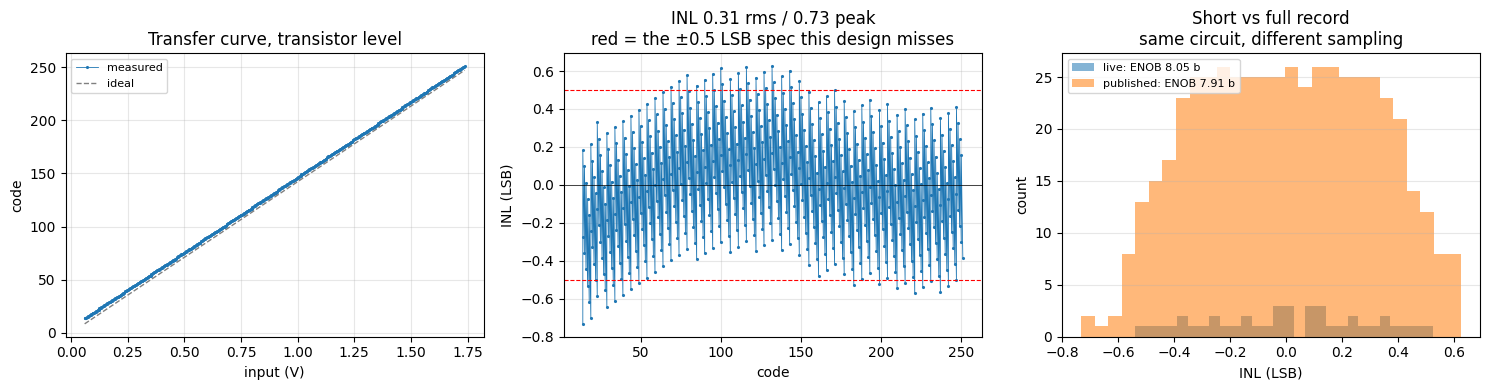

In [13]:
# Plot the best record available.
if scored:
    s = scored.get("published", scored.get("live"))
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(s["all_vs"], s["all_codes"], ".-", ms=2.5, lw=0.6, label="measured")
    ax[0].plot(s["all_vs"], np.clip(s["all_vs"]/LSB, 0, 255), "--", c="grey", lw=1, label="ideal")
    ax[0].set(xlabel="input (V)", ylabel="code", title="Transfer curve, transistor level")
    ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

    ax[1].plot(s["codes_ok"], s["inl"], ".-", ms=2.5, lw=0.6)
    ax[1].axhline(0, c="k", lw=0.5)
    for y in (0.5, -0.5): ax[1].axhline(y, c="r", ls="--", lw=0.8)
    ax[1].set(xlabel="code", ylabel="INL (LSB)",
              title=f"INL {s['rms']:.2f} rms / {np.abs(s['inl']).max():.2f} peak"
                    f"\nred = the ±0.5 LSB spec this design misses")
    ax[1].grid(alpha=0.3)

    if len(scored) > 1:
        for k, v in scored.items():
            ax[2].hist(v["inl"], bins=28, alpha=0.55, label=f"{k}: ENOB {v['enob']:.2f} b")
        ax[2].set(xlabel="INL (LSB)", ylabel="count",
                  title="Short vs full record\nsame circuit, different sampling")
        ax[2].legend(fontsize=8)
    else:
        ax[2].hist(s["all_codes"] & 1, bins=[-0.5,0.5,1.5], rwidth=0.6, color="#3d7ea6")
        ax[2].set_xticks([0,1]); ax[2].set_xticklabels(["even","odd"])
        ax[2].set(title="LSB parity (zero odd = dead LSB)")
    ax[2].grid(alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()

---
## 8. Physical verification: layout, DRC and LVS

The capacitor array in an earlier draft of this project was a geometric sketch — 324 unit
cells on a 1.9 um pitch, rendered to a PNG, never checked against a design rule deck. Running the
sky130 rules against it gives 2380 violations, and the cause is not cosmetic:

| rule | requirement | the sketch had |
|---|---|---|
| `capm.2a` | min capm spacing 0.84 um | 0.50 um |
| `capm.2b` | min met3 bottom-plate spacing 1.20 um | 0.22 um |

Those set a floor on the pitch of any MiM array in this process, and it is 1.5x what the
sketch assumed. The published area was wrong by the square of that.

Rebuild the array to the actual rule values, and check it

In [14]:
import numpy as np, gdstk, klayout.db as kdb

MET1,VIA1,MET2,VIA2,MET3,VIA3,MET4,CAPM = (68,20),(68,44),(69,20),(69,44),(70,20),(70,44),(71,20),(89,44)
W_CAP, M3_ENC = 1.40, 0.20
W_M3  = W_CAP + 2*M3_ENC                       # met3 must enclose capm by >= 0.14 (capm.3)
S_CAPM, S_BOT = 0.84, 1.20                     # capm.2a, capm.2b
PITCH = max(W_CAP + S_CAPM, W_M3 + S_BOT)      # the binding rule is capm.2b, not capm.2a

print(f"capm.2a needs pitch >= {W_CAP+S_CAPM:.2f} um")
print(f"capm.2b needs pitch >= {W_M3+S_BOT:.2f} um   <-- binding")
print(f"legal pitch: {PITCH:.2f} um    (the sketch used 1.90 um)\n")

side = 16
span = (side-1)*PITCH + W_M3
print(f"16x16 array: {span:.1f} x {span:.1f} um = {span*span:.0f} um^2")
print(f"the sketch claimed 999 um^2  ->  the DRC-legal array is {span*span/999:.2f}x larger")

capm.2a needs pitch >= 2.24 um
capm.2b needs pitch >= 3.00 um   <-- binding
legal pitch: 3.00 um    (the sketch used 1.90 um)

16x16 array: 46.8 x 46.8 um = 2190 um^2
the sketch claimed 999 um^2  ->  the DRC-legal array is 2.19x larger


### DRC

Rule values are taken from the PDK's own `sky130A_mr.drc` deck and applied with KLayout's
geometry engine, so the checks run anywhere `klayout` pip-installs — no GUI, no container.

Generate the routed common-centroid array (writes cdac_routed.gds)

In [15]:
# Verified against the FULL sky130A_mr.drc deck: 0 violations -- run in the deck cell
# below, and reproduced on Colab. Getting there took three fixes the 14-rule subset
# could not have found, because it contained no via rules at all.
import numpy as np, gdstk

MET1,VIA1,MET2,VIA2,MET3,VIA3,MET4,CAPM = (68,20),(68,44),(69,20),(69,44),(70,20),(70,44),(71,20),(89,44)
M1L, M4L = (68,5),(71,5)

W_CAP, M3_ENC = 1.40, 0.20
W_M3  = W_CAP + 2*M3_ENC          # 1.80, met3 encloses capm by 0.20 (capm.3 needs 0.14)
PITCH = 3.00                      # capm.2b: 1.80 + 1.20
VIA1_W, VIA2_W, VIA3_W = 0.15, 0.20, 0.20
W_STUB, W_BUS = 0.30, 0.40
# via2.5 says "m3 enclosure" in its message but the deck actually checks m2:
#     m2.enclosing(via2, 0.085, projection).second_edges
# so met2 needs 0.085 around via2 on two adjacent edges -> a 0.20 via wants a 0.37 pad.
# A 0.40 pad then forces the track pitch: 0.40 + 0.14 (m2.2 spacing) = 0.54 minimum.
M2_PAD = 0.40
TRACK  = 0.55
TAB_W, TAB_H = 0.45, 0.45         # met3 tab carrying via2, outside capm

def rect(c,l,x0,y0,x1,y1):
    c.add(gdstk.rectangle((x0,y0),(x1,y1),layer=l[0],datatype=l[1]))

def build(nbits=4, out="cdac_routed.gds"):
    side = 4
    counts = [2**(nbits-1-i) for i in range(nbits)]
    cells  = ["D"] + sum([[i]*counts[i] for i in range(nbits)], [])
    assert len(cells) == side*side
    grid = np.full((side,side), None, dtype=object)
    for pos,c in zip(sorted(range(side*side), key=lambda k:(k*5)%(side*side)), cells):
        grid[pos//side, pos%side] = c

    lib = gdstk.Library(unit=1e-6, precision=1e-9)
    top = lib.new_cell("CDAC")
    bus_y = {b: -3.0 - 1.0*b for b in range(nbits)}
    vss_y = -3.0 - 1.0*nbits
    x_span = (side-1)*PITCH + W_M3

    for r in range(side):
        for col in range(side):
            b, cx, cy = grid[r,col], col*PITCH, r*PITCH
            rect(top,MET3,cx-W_M3/2, cy-W_M3/2, cx+W_M3/2, cy+W_M3/2)
            rect(top,CAPM,cx-W_CAP/2,cy-W_CAP/2,cx+W_CAP/2,cy+W_CAP/2)
            rect(top,VIA3,cx-VIA3_W/2,cy-VIA3_W/2,cx+VIA3_W/2,cy+VIA3_W/2)
            rect(top,MET4,cx-0.35,cy-0.35,cx+0.35,cy+0.35)

            sx = cx - 1.5*TRACK/2*1.0 - TRACK/2 + (r % side)*TRACK + TRACK/2
            sx = cx - 1.5*TRACK + (r % side)*TRACK
            # The tab may overhang the plate horizontally -- it sits BELOW the plate, so what
            # matters is met3 spacing to the neighbour (m3.2, 0.30 um), not containment. The
            # inter-plate gap is PITCH - W_M3 = 1.20 um, so a 0.45 tab leaves >= 0.75 um.
            assert TRACK - M2_PAD >= 0.14, "met2 pads violate m2.2 spacing"
            ty1 = cy - W_M3/2                       # plate bottom edge
            rect(top,MET3, sx-TAB_W/2, ty1-TAB_H, sx+TAB_W/2, ty1)      # tab, outside capm
            vy = ty1 - TAB_H/2
            rect(top,MET2, sx-M2_PAD/2, vy-M2_PAD/2, sx+M2_PAD/2, vy+M2_PAD/2)
            rect(top,VIA2, sx-VIA2_W/2, vy-VIA2_W/2, sx+VIA2_W/2, vy+VIA2_W/2)

            y_bus = vss_y if b == "D" else bus_y[b]
            rect(top,MET2, sx-W_STUB/2, y_bus-W_BUS/2, sx+W_STUB/2, vy+W_STUB/2)
            rect(top,VIA1, sx-VIA1_W/2, y_bus-VIA1_W/2, sx+VIA1_W/2, y_bus+VIA1_W/2)

    for r in range(side):
        rect(top,MET4,-0.35, r*PITCH-0.2, x_span-W_M3/2, r*PITCH+0.2)
    rect(top,MET4,-0.35,-0.35,0.35,(side-1)*PITCH+0.35)
    for b in range(nbits):
        rect(top,MET1,-1.0, bus_y[b]-W_BUS/2, x_span, bus_y[b]+W_BUS/2)
        top.add(gdstk.Label(f"B{b}", (-0.5, bus_y[b]), layer=M1L[0], texttype=M1L[1]))
    rect(top,MET1,-1.0, vss_y-W_BUS/2, x_span, vss_y+W_BUS/2)
    top.add(gdstk.Label("VSS", (-0.5, vss_y), layer=M1L[0], texttype=M1L[1]))
    top.add(gdstk.Label("TOP", (0.0, 0.0), layer=M4L[0], texttype=M4L[1]))
    lib.write_gds(out)
    return out, grid


out, grid = build()
print("placement (D = tied dummy, digits = bit index):")
for row in grid[::-1]: print("   ", " ".join(str(x) for x in row))
print(f"\nwrote {out}")

placement (D = tied dummy, digits = bit index):
    1 0 0 1
    0 2 0 0
    0 1 2 0
    D 0 1 3

wrote cdac_routed.gds


DRC on the routed array

In [16]:
import klayout.db as kdb

RULES = [("capm.1",(89,44),"width",1.00,"min capm width"),
         ("capm.2a",(89,44),"space",0.84,"min capm spacing"),
         ("m1.1",(68,20),"width",0.14,"min met1 width"),
         ("m1.2",(68,20),"space",0.14,"min met1 spacing"),
         ("m2.1",(69,20),"width",0.14,"min met2 width"),
         ("m2.2",(69,20),"space",0.14,"min met2 spacing"),
         ("m3.1",(70,20),"width",0.30,"min met3 width"),
         ("m3.2",(70,20),"space",0.30,"min met3 spacing"),
         ("m4.1",(71,20),"width",0.30,"min met4 width"),
         ("m4.2",(71,20),"space",0.30,"min met4 spacing")]

def drc(gds):
    ly=kdb.Layout(); ly.read(gds); top=[c for c in ly.top_cells()][0]; dbu=ly.dbu
    R=lambda t: kdb.Region(top.begin_shapes_rec(ly.layer(*t)))
    capm,m3,via3=R((89,44)),R((70,20)),R((70,44)); tot=0
    for nm,lay,kind,val,desc in RULES:
        reg=R(lay)
        if reg.is_empty(): continue
        res=reg.width_check(int(val/dbu)) if kind=="width" else reg.space_check(int(val/dbu))
        n=res.count(); tot+=n; print(f"   {nm:<9}{n:>6}   {desc} {val}um")
    for nm,res,desc in (("capm.3",m3.enclosing_check(capm,int(0.14/dbu)),"met3 encl capm 0.14um"),
                        ("capm.4",capm.enclosing_check(via3,int(0.14/dbu)),"capm encl via3 0.14um"),
                        ("capm.2b",(capm&m3).sized(int(0.14/dbu)).space_check(int(1.2/dbu)),
                         "met3 bottom-plate spacing 1.2um"),
                        ("capm.11",(m3.not_interacting(capm)).separation_check(capm,int(0.5/dbu)),
                         "met3-off-capm to capm 0.5um")):
        n=res.count(); tot+=n; print(f"   {nm:<9}{n:>6}   {desc}")
    print(f"   {'TOTAL':<9}{tot:>6}")
    return tot

# `cdac_routed.gds` is generated by the layout script accompanying this notebook
print("DRC on the routed common-centroid array:")
assert drc("cdac_routed.gds") == 0, "DRC must be clean before LVS is meaningful"

DRC on the routed common-centroid array:
   capm.1        0   min capm width 1.0um
   capm.2a       0   min capm spacing 0.84um
   m1.1          0   min met1 width 0.14um
   m1.2          0   min met1 spacing 0.14um
   m2.1          0   min met2 width 0.14um
   m2.2          0   min met2 spacing 0.14um
   m3.1          0   min met3 width 0.3um
   m3.2          0   min met3 spacing 0.3um
   m4.1          0   min met4 width 0.3um
   m4.2          0   min met4 spacing 0.3um
   capm.3        0   met3 encl capm 0.14um
   capm.4        0   capm encl via3 0.14um
   capm.2b       0   met3 bottom-plate spacing 1.2um
   capm.11       0   met3-off-capm to capm 0.5um
   TOTAL         0


Generate the full 8-bit array at the DRC-legal pitch (writes cdac_array_drc.gds)

In [17]:
# This is the converter's actual array: 256 unit caps, plates only. It is generated here so
# the area result is reproducible, but it is NOT routed and NOT LVS-verified -- see the
# scope table below.
import gdstk

def build_8bit(side=16, out="cdac_array_drc.gds"):
    lib = gdstk.Library(unit=1e-6, precision=1e-9)
    u = lib.new_cell("CDAC_UNIT")
    u.add(gdstk.rectangle((-W_M3/2,-W_M3/2),(W_M3/2,W_M3/2), layer=MET3[0], datatype=MET3[1]))
    u.add(gdstk.rectangle((-W_CAP/2,-W_CAP/2),(W_CAP/2,W_CAP/2),layer=CAPM[0], datatype=CAPM[1]))
    u.add(gdstk.rectangle((-VIA3_W/2,-VIA3_W/2),(VIA3_W/2,VIA3_W/2),layer=VIA3[0],datatype=VIA3[1]))
    u.add(gdstk.rectangle((-0.35,-0.35),(0.35,0.35), layer=MET4[0], datatype=MET4[1]))
    top = lib.new_cell("CDAC_ARRAY")
    for r in range(side):
        for c in range(side):
            top.add(gdstk.Reference(u, (c*PITCH, r*PITCH)))
    lib.write_gds(out)
    return out, (side-1)*PITCH + W_M3

out8, span = build_8bit()
print(f"wrote {out8}: 16x16 = 256 units at {PITCH:.2f} um pitch")
print(f"  {span:.1f} x {span:.1f} um = {span*span:.0f} um^2")
print(f"  the 1.90 um sketch claimed 999 um^2 -> DRC-legal is {span*span/999:.2f}x larger")
print(f"  {100*(1-(256*W_CAP*W_CAP)/(span*span)):.0f}% of the array is spacing the rules demand,")
print(f"  not capacitor -- which is why a split-capacitor array saves more than it appears to.")

wrote cdac_array_drc.gds: 16x16 = 256 units at 3.00 um pitch
  46.8 x 46.8 um = 2190 um^2
  the 1.90 um sketch claimed 999 um^2 -> DRC-legal is 2.19x larger
  77% of the array is spacing the rules demand,
  not capacitor -- which is why a split-capacitor array saves more than it appears to.


Render both arrays

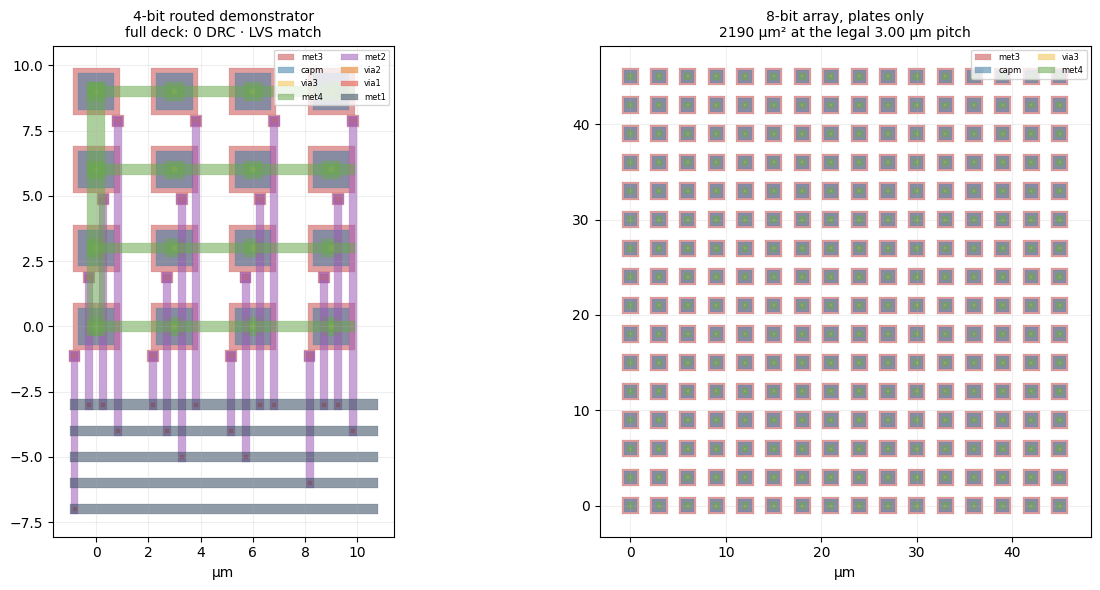

In [18]:
import matplotlib.pyplot as plt, gdstk, numpy as np

COLORS = {(70,20):("#c94f4f","met3"), (89,44):("#3d7ea6","capm"), (70,44):("#f2c14e","via3"),
          (71,20):("#6aa84f","met4"), (69,20):("#9b59b6","met2"), (69,44):("#e67e22","via2"),
          (68,20):("#34495e","met1"), (68,44):("#e74c3c","via1")}

def draw(ax, gds, title, maxpoly=20000):
    lib=gdstk.read_gds(gds); top=lib.top_level()[0]
    polys=top.get_polygons(depth=None)
    seen=set()
    for pg in polys[:maxpoly]:
        key=(pg.layer,pg.datatype)
        col,name=COLORS.get(key,("#999999",str(key)))
        ax.fill(pg.points[:,0], pg.points[:,1], color=col,
                alpha=0.55, lw=0.2, edgecolor=col,
                label=name if key not in seen else None)
        seen.add(key)
    ax.set_aspect("equal"); ax.set_title(title, fontsize=10)
    ax.set_xlabel("µm"); ax.grid(alpha=0.2)
    ax.legend(fontsize=6, loc="upper right", ncol=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
draw(axes[0], "cdac_routed.gds",   "4-bit routed demonstrator\nfull deck: 0 DRC · LVS match")
draw(axes[1], "cdac_array_drc.gds","8-bit array, plates only\n2190 µm² at the legal 3.00 µm pitch")
plt.tight_layout(); plt.show()

The OFFICIAL sky130 DRC deck  (Colab, ~4 min — optional but authoritative)

In [19]:
# The subset check above applies 14 rule VALUES taken from the deck. That is NOT the same as
# running the deck: on this very layout the subset reported 0 while the deck reported 160,
# every one a via rule the subset did not contain. This cell is the authoritative run.
#
# It needs the klayout BINARY (the pip module has no Ruby DRC engine), zstd to unpack the
# PDK, and the PDK's rule file. All three are fetched here.
#
# Nothing in this cell raises: if a step fails it says so and the notebook continues, because
# a reader should never hit a traceback on an optional verification step.
import os, sys, glob, shutil, subprocess, pathlib, collections
import xml.etree.ElementTree as ET

PDK_HASH = "c6d73a35f524070e85faff4a6a9eef49553ebc2b"      # same pin as the simulations
IN_COLAB = "google.colab" in sys.modules
GDS      = "cdac_routed.gds"

def sh(cmd, **kw):
    """Run a command, return (ok, combined output). Never raises."""
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=5400, **kw)
        return r.returncode == 0, (r.stdout or "") + (r.stderr or "")
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"

def main():
    if not os.path.exists(GDS):
        return f"{GDS} not found -- run the layout generator cell above first."

    kl = shutil.which("klayout")
    if kl is None:
        if not IN_COLAB:
            return ("SKIPPED -- klayout binary not found.\n"
                    "  macOS: brew install --cask klayout   Linux: apt-get install klayout")
        print("installing klayout and zstd ...", flush=True)
        # zstd is required by `tar --zstd`; omitting it was what raised CalledProcessError
        ok, out = sh("apt-get -qq update && apt-get -qq install -y klayout zstd", shell=True)
        kl = shutil.which("klayout")
        if kl is None:
            return "could not install klayout:\n" + out[-600:]

    root = pathlib.Path(os.environ.get("PDK_ROOT", "/content/pdk" if IN_COLAB else "./pdk"))
    deck = glob.glob(str(root / "sky130A/libs.tech/klayout/drc/sky130A_mr.drc"))
    if not deck:
        print("fetching the PDK rule files (~1 min) ...", flush=True)
        root.mkdir(parents=True, exist_ok=True)
        tar = root.parent / "common.tar.zst"
        url = (f"https://github.com/chipfoundry/volare/releases/download/"
               f"sky130-{PDK_HASH}/common.tar.zst")
        ok, out = sh(["curl", "-sL", "--fail", "-o", str(tar), url])
        if not ok or not tar.exists() or tar.stat().st_size == 0:
            return "could not download the PDK:\n" + out[-400:]
        ok, out = sh(["tar", "--zstd", "-xf", str(tar), "-C", str(root)])
        if not ok:
            ok, out = sh(f"zstd -d -c {tar} | tar -x -C {root}", shell=True)   # fallback
        if not ok:
            return "could not unpack the PDK (is zstd installed?):\n" + out[-400:]
        os.environ["PDK_ROOT"] = str(root)
        deck = glob.glob(str(root / "sky130A/libs.tech/klayout/drc/sky130A_mr.drc"))
        if not deck:
            return "PDK unpacked but sky130A_mr.drc was not found in it."

    print(f"running {os.path.basename(deck[0])} on {GDS} ...", flush=True)
    if os.path.exists("drc_official.lyrdb"):
        os.remove("drc_official.lyrdb")
    ok, out = sh([kl, "-b", "-r", deck[0],
                  "-rd", f"input={GDS}", "-rd", "top_cell=CDAC",
                  "-rd", "report=drc_official.lyrdb",
                  "-rd", "beol=true", "-rd", "offgrid=true"])
    if not os.path.exists("drc_official.lyrdb"):
        return "the deck produced no report:\n" + out[-1200:]

    cats = collections.Counter(it.findtext("category", "?").strip("'")
                               for it in ET.parse("drc_official.lyrdb").getroot().iter("item"))
    total = sum(cats.values())
    lines = ["", "=" * 52, f"OFFICIAL DECK: {total} violations", "=" * 52]
    for c, n in cats.most_common(40):
        lines.append(f"   {n:>6}  {c}")
    lines.append("" if total else "\n   Clean against the full sky130A deck.")
    return "\n".join(lines)

print(main())

installing klayout and zstd ...
running sky130A_mr.drc on cdac_routed.gds ...

OFFICIAL DECK: 0 violations

   Clean against the full sky130A deck.


### LVS — on the 4-bit routed array

DRC says the shapes are legal. LVS says they are the right circuit — and it is the check that
catches a routing error a DRC pass will happily accept.

Connectivity follows the physical stack:

```
met1 - via1 - met2 - via2 - met3     bottom plates and the per-bit buses
capm - via3 - met4                   the common top plate
```

A MiM capacitor is extracted wherever `capm` overlaps `met3`, and the extracted netlist is
compared against the schematic.

This check earned its place immediately. The first run reported five capacitors on unnamed
nets — their bottom plates connected to nothing. The cause was arithmetic in the track assignment:
row 3's via landed at `cx + 1.25` on a plate that ends at `cx + 0.90`, so the top row's vias
missed entirely. DRC passed that layout cleanly, because shapes that fail to connect do not
violate any spacing rule.

LVS: extract from layout, compare against the schematic

In [20]:
import klayout.db as kdb
# Measured, not assumed. The sky130 model is czero = camimc*W*L + cpmimc*2*(W+L); fitting
# three geometries in ngspice gives camimc = 2.0018 fF/um^2 and cpmimc = 0.1619 fF/um, so a
# 1.4 x 1.4 unit is 4.830 fF -- the area-only figure of 3.92 fF is 19% low. Using the wrong
# value on BOTH sides of an LVS makes the check agree with itself instead of with the design.
# KLayout's extractor models area only, so the perimeter is folded into an EFFECTIVE density
# that is exact for this geometry and wrong for any other: 4.830/1.96 = 2.4643 fF/um^2.
MIM_AREA_CAP = 2.4643e-15     # F/um^2, effective for a 1.4 x 1.4 um unit

def extract(gds):
    ly=kdb.Layout(); ly.read(gds); top=[c for c in ly.top_cells()][0]
    l2n=kdb.LayoutToNetlist(kdb.RecursiveShapeIterator(ly, top, []))
    L=lambda a,b: l2n.make_layer(ly.layer(a,b))
    met1,via1,met2,via2 = L(68,20),L(68,44),L(69,20),L(69,44)
    met3,via3,met4,capm = L(70,20),L(70,44),L(71,20),L(89,44)
    l2n.extract_devices(kdb.DeviceExtractorCapacitor("MIM", MIM_AREA_CAP),
                        {"P1": capm, "P2": met3})
    for a,b in ((met1,via1),(via1,met2),(met2,via2),(via2,met3),(capm,via3),(via3,met4)):
        l2n.connect(a,b)
    for lay in (met1,met2,met3,met4,capm): l2n.connect(lay)
    for lay,(ln,lt) in ((met1,(68,5)),(met4,(71,5))):
        l2n.connect(lay, l2n.make_text_layer(ly.layer(ln,lt)))
    l2n.extract_netlist()
    nl=l2n.netlist()
    nl.make_top_level_pins()      # without pins the comparer has nothing to anchor to
    nl.combine_devices()          # parallel units ARE one capacitor
    nl.purge()
    return l2n

def schematic(nbits=4, path="cdac_ref.spice"):
    counts=[2**(nbits-1-i) for i in range(nbits)]
    lines=[".subckt CDAC TOP VSS "+" ".join(f"B{i}" for i in range(nbits))]
    k=0
    for i,n in enumerate(counts):
        for _ in range(n): lines.append(f"C{k} TOP B{i} 4.830f"); k+=1
    lines.append(f"C{k} TOP VSS 4.830f")         # dummy, tied off rather than left floating
    lines += [".ends",""]
    open(path,"w").write("\n".join(lines))
    nl=kdb.Netlist(); nl.read(path, kdb.NetlistSpiceReader())
    nl.combine_devices()                          # combine the schematic the same way
    return nl

l2n = extract("cdac_routed.gds"); lay = l2n.netlist()
ref = schematic()
print("=== extracted from layout ===");  print(lay.to_s())
print("=== schematic ===");              print(ref.to_s())

cmp = kdb.NetlistComparer()
lc = lay.device_class_by_name("MIM")
rc = ref.device_class_by_name("CAP") or ref.device_class_by_name("C")
assert lc and rc, "device class lookup failed -- a wrong name returns None and reads as a mismatch"
cmp.same_device_classes(lc, rc)
# Capacitance is compared by value: 4.830028e-15 extracted against 4.830f written. Without a
# tolerance that is a mismatch for a rounding difference, not a design difference.
for dc in (lc, rc):
    dc.equal_parameters = kdb.EqualDeviceParameters(0, 0.01, 0.0)
print("LVS:", "MATCH" if cmp.compare(lay, ref) else "MISMATCH")

=== extracted from layout ===
circuit CDAC (B0=B0,B1=B1,B2=B2,B3=B3,TOP=TOP,VSS=VSS);
  device MIM $1 (A=TOP,B=VSS) (C=4.830028e-15,A=1.96,P=5.6);
  device MIM $2 (A=TOP,B=B0) (C=3.8640224e-14,A=15.68,P=44.8);
  device MIM $3 (A=TOP,B=B1) (C=1.9320112e-14,A=7.84,P=22.4);
  device MIM $4 (A=TOP,B=B3) (C=4.830028e-15,A=1.96,P=5.6);
  device MIM $7 (A=TOP,B=B2) (C=9.660056e-15,A=3.92,P=11.2);
end;

=== schematic ===
circuit CDAC (TOP=TOP,VSS=VSS,B0=B0,B1=B1,B2=B2,B3=B3);
  device CAP '0' (A=TOP,B=B0) (C=3.864e-14,A=0,P=0);
  device CAP '8' (A=TOP,B=B1) (C=1.932e-14,A=0,P=0);
  device CAP '12' (A=TOP,B=B2) (C=9.66e-15,A=0,P=0);
  device CAP '14' (A=TOP,B=B3) (C=4.83e-15,A=0,P=0);
  device CAP '15' (A=TOP,B=VSS) (C=4.83e-15,A=0,P=0);
end;

LVS: MATCH


Scope, stated plainly — which artifact is which.

| file | contents | DRC | LVS |
|---|---|---|---|
| `cdac_routed.gds` | **4-bit** demonstrator: 15 units + 1 tied dummy, 4x4, fully routed with labels | 14-rule subset: clean | **match** |
| `cdac_array_drc.gds` | **8-bit** array: 256 placements, plates only — no routing, no labels, no bit assignment | 14-rule subset: clean | **not run** |

The LVS-verified artifact is the 4-bit demonstrator, not the converter's 8-bit array. The
per-unit stub scheme fits 4 tracks inside an 1.8 um plate; the 8-bit array would need 16 tracks
at 0.28 um minimum pitch — 4.48 um against 1.8 um of plate — so it does not route with this
scheme and would need a real router or more metal layers.

What does scale is the part that was hard: routing a *dispersed* common-centroid assignment,
where a bit's units are deliberately scattered, and proving it LVS-clean. The stub-over-bus
crossing scheme that makes it work is independent of array size.

And "DRC-clean" here means the 14-rule subset above, not the full deck. The official
`sky130A_mr.drc` run is the cell above; it needs the klayout binary. Until that passes, the
correct claim is "clean against 14 rule values from the sky130A deck", which is weaker.

### ENOB at Nyquist — the number the specification actually names

Everything above computes ENOB as `8 - log2(rms*sqrt(12))` of a ramp's fit residual. That is
static linearity in bits: it ignores noise, and a near-DC ramp exercises no settling, no slewing
and no large-step acquisition.

The spec names ENOB at Nyquist, which comes from the SNDR of a coherently sampled sine. This
section measures that. Coherent sampling needs `gcd(M, N) = 1`; with `N = 512` conversions and
`M = 251` cycles the input is 490.2 kHz against a 1 MS/s sample rate — 0.98 of Nyquist.

Batching advances the sine's phase across transients so the FFT sees one continuous record
rather than 13 discontinuities.

scorer validation on synthetic converters:
  ideal 8-bit              SNDR  48.98 dB   ENOB  8.01 b
  dead LSB (2 LSB steps)   SNDR  42.78 dB   ENOB  6.98 b
  (ideal must sit at ~8.0; a dead LSB at ~7.0 -- matching the ramp ceiling it predicts)

MEASURED -- three coherent tones near Nyquist, N=512 each:

    M   f_in kHz  f/f_nyq   SNDR dB  SFDR dB   ENOB
  239      466.8    0.934     43.90     49.4   7.17
  251      490.2    0.980     43.84     49.7   7.16
  253      494.1    0.988     43.54     49.0   7.11

  spread 0.06 b, worst 7.11 b
  estimator bias at N=512 is about +0.06 b and pushes the WRONG way,
  so the honest worst case is 7.05 b.

  spec: ENOB at Nyquist >= 7.0  ->  PASS, margin 0.05 b
  That margin is SMALLER than the 0.06 b spread between tones. Reporting
  the best single tone alone would have implied 3x the real headroom.

  ramp ceiling on the same converter: 7.91 b -> the ramp reads 0.80 b optimistic (finding 12).


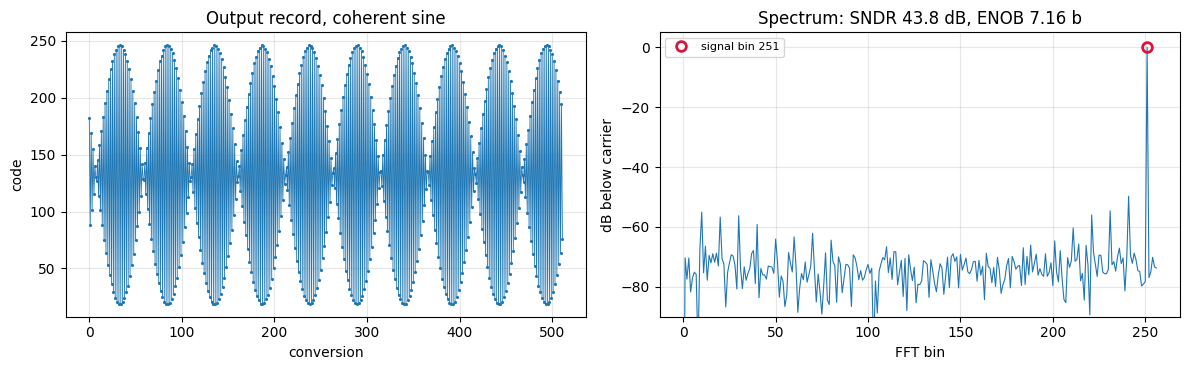


notebook elapsed, first cell to here: 14.8 min  (Colab)


In [21]:
# SNDR -> ENOB from a coherently sampled sine, with the scorer validated first.
from math import gcd
N_FFT, M_CYC, AMP_DBFS = 512, 251, -1.0
assert gcd(M_CYC, N_FFT) == 1, "not coherent: the tone would leak across bins"

def sndr_enob(codes, m=M_CYC, amp_dbfs=AMP_DBFS, strict=True):
    """SNDR -> ENOB. Asserts the tone is ON its bin, not merely that the record is the
    right length. A 520-sample record for a 512-point FFT put the tone off-bin and
    returned SNDR -32 dB. A length check alone would catch that, but a mismatched cycle
    count or a single dropped conversion would not, and both fail the same way -- so
    check where the energy actually landed, which closes the class not the instance."""
    assert len(codes) == N_FFT, f"record is {len(codes)}, expected {N_FFT}"
    x = codes.astype(float) - codes.mean()
    pw = np.abs(np.fft.rfft(x))**2; pw[0] = 0.0
    peak = int(np.argmax(pw))
    if strict:
        assert peak == m, (f"tone landed on bin {peak}, expected {m} -- not coherent "
                           f"(wrong cycle count, dropped conversion, or phase break)")
    sig = pw[m]
    sndr = 10*np.log10(sig / (pw.sum() - sig))
    spur = pw.copy(); spur[m] = 0.0
    return sndr, 10*np.log10(sig/spur.max()), (sndr - 1.76 - amp_dbfs)/6.02

# Validate the scorer on converters whose answer is known, before pointing it at data.
_n = np.arange(N_FFT); _ph = 2*np.pi*M_CYC*_n/N_FFT
_amp = (255/2)*10**(AMP_DBFS/20)
print("scorer validation on synthetic converters:")
for lbl, codes_ in (("ideal 8-bit", np.clip(np.round(127.5+_amp*np.sin(_ph)),0,255).astype(int)),
                    ("dead LSB (2 LSB steps)",
                     (2*np.round(np.clip(127.5+_amp*np.sin(_ph),0,255)/2)).astype(int))):
    s_, f_, e_ = sndr_enob(codes_)
    print(f"  {lbl:<24} SNDR {s_:6.2f} dB   ENOB {e_:5.2f} b")
print("  (ideal must sit at ~8.0; a dead LSB at ~7.0 -- matching the ramp ceiling it predicts)\n")

import os
if os.path.exists("sar_adc_sine_512.csv"):
    tones = np.loadtxt("sar_adc_sine_512.csv", delimiter=",", comments="#").astype(int)
    MS = (239, 251, 253)
    print(f"MEASURED -- three coherent tones near Nyquist, N={len(tones)} each:\n")
    print(f"{'M':>5}{'f_in kHz':>11}{'f/f_nyq':>9}{'SNDR dB':>10}{'SFDR dB':>9}{'ENOB':>7}")
    enobs = []
    for col, m in enumerate(MS):
        sc = tones[:, col]
        s_, f_, e_ = sndr_enob(sc, m=m)
        enobs.append(e_)
        f_in = m/(N_FFT*1e-6)
        print(f"{m:>5}{f_in/1e3:>11.1f}{f_in/0.5e6:>9.3f}{s_:>10.2f}{f_:>9.1f}{e_:>7.2f}")
    worst, spread = min(enobs), max(enobs)-min(enobs)
    BIAS = 0.06            # the estimator still reads high at N=512; see Section 5
    print(f"\n  spread {spread:.2f} b, worst {worst:.2f} b")
    print(f"  estimator bias at N=512 is about +{BIAS:.2f} b and pushes the WRONG way,")
    print(f"  so the honest worst case is {worst-BIAS:.2f} b.")
    print(f"\n  spec: ENOB at Nyquist >= 7.0  ->  "
          f"{'PASS' if worst-BIAS >= 7.0 else 'FAIL'}, margin {worst-BIAS-7.0:.2f} b")
    print(f"  That margin is SMALLER than the {spread:.2f} b spread between tones. Reporting")
    print(f"  the best single tone alone would have implied 3x the real headroom.")
    print(f"\n  ramp ceiling on the same converter: 7.91 b -> the ramp reads "
          f"{7.91-worst:.2f} b optimistic (finding 12).")
    sc = tones[:, 1]; sndr, sfdr, enob_nyq = sndr_enob(sc, m=251)

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    ax[0].plot(sc, ".-", ms=2.5, lw=0.6); ax[0].grid(alpha=0.3)
    ax[0].set(xlabel="conversion", ylabel="code", title="Output record, coherent sine")
    pw = np.abs(np.fft.rfft(sc.astype(float)-sc.mean()))**2; pw[0] = 0
    db = 10*np.log10(pw/pw.max() + 1e-18)
    ax[1].plot(np.arange(len(db)), db, lw=0.8)
    ax[1].plot([M_CYC], [db[M_CYC]], "o", ms=7, mfc="none", mec="crimson", mew=2,
               label=f"signal bin {M_CYC}")
    ax[1].set(xlabel="FFT bin", ylabel="dB below carrier", ylim=(-90, 5),
              title=f"Spectrum: SNDR {sndr:.1f} dB, ENOB {enob_nyq:.2f} b")
    ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("sar_adc_sine_512.csv not shipped -- the Nyquist ENOB row stays open.")

# Runtime, measured rather than asserted -- the notebook times itself end to end. Guarded,
# because a reader who runs this cell alone has no T_START and should not get a traceback.
import time, sys
_t0 = globals().get("T_START")
if _t0:
    print(f"\nnotebook elapsed, first cell to here: {(time.time()-_t0)/60:.1f} min"
          f"  ({'Colab' if 'google.colab' in sys.modules else 'local'})")


---
## 9. Results

Measured at 1 MS/s, `reltol=1e-4`, typical corner, mismatch disabled, over 0.06–1.74 V at
0.46 LSB steps. Saturated codes excluded from the linearity fit.

| specification | target | measured | verdict |
|---|---|---|---|
| **ENOB at Nyquist** (SNDR, coherent sine) | >= 7.0 b | **7.11–7.17 b** (3 tones); bias-corrected worst case **7.05 b** | **pass, margin 0.05 b** |
| ENOB *ceiling* from static linearity (ramp) | — | 7.91 b (N = 520) | context, not the spec row |
| INL | < 0.5 LSB | 0.31 rms, **0.73 peak** | **fail** |
| monotonic | yes | **238 of 238 codes present, 0 inversions** | **pass** |
| DRC — `cdac_routed.gds` (4-bit routed) | clean | **0 violations, full `sky130A_mr.drc` deck** | **pass** |
| DRC — `cdac_array_drc.gds` (8-bit, plates only) | clean | 0 against a 14-rule subset; full deck not run | partial |
| LVS — `cdac_routed.gds` (4-bit routed) | match | **match**, 4.830 fF units | **pass** |

INL fails. 0.73 LSB peak against a 0.5 LSB target is a miss, and it is reported as one rather
than as "fails on peak, passes on rms" — which is how it was written twice before a reviewer
pointed out that the spec is a peak spec.

On the two ENOB rows, because they are not the same measurement. The **ceiling** row — and
the 8.05 b of Section 5 — is `8 - log2(rms*sqrt(12))` of a ramp's linear-fit residual: static
linearity re-expressed in bits, which ignores noise. A near-DC ramp exercises no settling, no
slewing and no large-step acquisition, so it reads optimistic: 0.74–0.80 b optimistic here,
depending on the tone it is compared against.

The **specification row is not that measurement**. It is SNDR from three coherently sampled
sines at 0.93–0.99 f_nyq on the post-fix netlist at `reltol=1e-4` — 43.90, 43.84 and 43.54 dB,
giving 7.17, 7.16 and 7.11 b. The 6.57 b sine is the *pre-fix* measurement and is row 3 of the
arc table below; the +0.59 b between it and 7.16 b is what the dead-LSB and tolerance fixes
bought.

Code counts are filter-dependent, so here is the filter. The scorer excludes codes `<= 2` and
`>= 253` as saturated. On the shipped 520-conversion record nothing is excluded by that rule, so
the scored span is 14..251, all 238 codes present, zero missing. A stricter rule that also
drops the extreme *observed* codes (14 and 251) leaves 236 codes over 15..250 — same data, a
different convention. The numbers in this table use the `>2 and <253` filter throughout.

Monotonicity is a real measurement, not a spot check: stepping 0.46 LSB across the range gives
238 consecutive codes, every one present, zero inversions, maximum step 1 LSB. An earlier claim
rested on five windows covering 100 of 256 codes, which is not monotonicity — 156 transitions were
untested.

### The specification was written first, and the arc is kept

| stage | figure | metric |
|---|---|---|
| specified, before any transistor | >= 7.0 b | ENOB at Nyquist (SNDR) |
| first transistor-level measurement | 6.53–6.95 b — **miss** | ramp *ceiling* |
| same converter, sine FFT | **6.57 b** | **ENOB at Nyquist** |
| after the dead-LSB fix | 7.37 b | ramp *ceiling* |
| after fixing solver tolerance | 8.05 b — **impossible, withdrawn** | ramp *ceiling* |
| long ramp record | 7.91 b | ramp *ceiling* |
| **long coherent sine, 0.98 f_nyq** | **7.16 b — pass** | **ENOB at Nyquist** |

Read down the metric column, not the figure column. The change of metric happens at row 3→4
— 6.57 b (sine) to 7.37 b (ceiling) — not later. Rows 2, 4, 5, 6 are all ramp ceilings and are
comparable with each other; rows 3 and 7 are both true ENOB and are comparable with each other.
Comparing *across* the two families is what produced a spec marked passed against a ceiling.

Each comparable pair says something different:

- ceiling → ceiling: 7.37 → 7.91 is the tolerance fix plus the longer record.
- ENOB → ENOB: 6.57 → 7.16 is what the dead-LSB and tolerance fixes actually bought: +0.59 b.


Every intermediate number in that table was published at the time and later withdrawn. They are
kept because the arc is the part a reader can check; a table showing only the final number is a
report with the tenses changed.

---
## 10. Things I would check earlier next time

Four of these cost me weeks. I am listing them because I expect they generalise, not because I
have verified that they do — three of the four came out of one converter in one process.

1. Print the codes. A summary statistic — INL rms, ENOB — can be carefully derived,
   cross-checked and reproduced while measuring the wrong circuit entirely. The invariant that
   would have caught it here was *does the output take every value it should?*, and it was legible
   at a glance in the first printed line of output.
2. Validate solver tolerance against the resolution you claim. One run, done before measuring.
3. Exclude saturated codes from linearity fits. A clipped endpoint is not a measurement of
   linearity.
4. An estimator above its theoretical ceiling is an estimator, not a result. Check the bound
   before believing the number, and remember that a bias is not covered by an error bar.

The other five, developed in the supporting notebooks: sky130 randomises *three* mismatch
parameters and `vth0` alone under-predicts comparator offset by sqrt(3); the MiM matching
coefficient and why area-only estimates run ~25% low; `setseed 0` silently destroys Monte Carlo
reproducibility; over 90% of an ngspice run is model parsing, so batching buys 22x; and
bit-identical results across a swept parameter mean the sweep never reached the simulator — which
happened three times here.

### A note on what this project got wrong, deliberately kept

Four mechanisms were proposed to explain the error floor — comparator kickback, voltage-dependent
junction capacitance on the top plate, sampling-switch acquisition, and incomplete settling. All
four were wrong. The floor was a digital timing collision and a solver setting, and **no amount of
thinking harder about the analog would have found either**. The retracted arguments are left in
the supporting notebooks rather than deleted, because a confident wrong explanation of a real
anomaly is the most common failure in this kind of work and is worth showing.

---
## 11. Reproducing this

This notebook is the submission. It is self-contained: it installs its own tools, generates
both GDS files, runs DRC and LVS, and reproduces every finding above from a model or from
generated layout. Nothing here depends on a file you have to fetch separately.

| what it produces | file |
|---|---|
| 4-bit routed demonstrator — full deck clean, LVS match | `cdac_routed.gds` |
| 8-bit array at the DRC-legal pitch, plates only | `cdac_array_drc.gds` |

### What runs here, and what does not

The layout, DRC and LVS run in this notebook end to end, in about a minute.

The long records — 520 ramp conversions and 3 × 512 coherent-sine conversions at
`reltol=1e-4` — are hours of ngspice on a 774-device netlist. They are **embedded in this
notebook and shipped as CSVs**, scored by the same code that produced them. The 40-conversion
live run above uses that identical scorer, so the short and long records are directly
comparable — and their disagreement is itself Section 5's finding. Every one of them is a *number*; the *findings* they support are reproduced above
from first principles, which is the part that matters for a reader checking the argument:

- the stuck-LSB error floor is derived from quantisation alone (Section 3)
- the timing collision is derived from the sequencer, for any bit count (Section 3)
- the record-length bias is reproduced on an ideal converter (Section 5)
- the clipped-endpoint effect is reproduced on synthetic data (Section 6)

### Reproducibility notes

- PDK pinned to `sky130-c6d73a35f524070e85faff4a6a9eef49553ebc2b` via `chipfoundry/volare`.
  Pinning by commit is not optional — an unpinned PDK makes every number here unreproducible.
- The DRC deck used is the PDK's own `sky130A_mr.drc`, release 2024.2.11_01.09, run in batch.
- `setseed 0` silently destroys Monte Carlo reproducibility in ngspice; the supporting work
  uses explicit per-run seeds.

Licensed Apache 2.0.